# Rosetta — Analyse Exploratoire de Données (AED)

**Dataset :** `Helsinki-NLP/tatoeba`, paire de langues `en` ↔ `fr` (corpus parallèle OPUS-Tatoeba).

Ce notebook couvre le **début de l'AED** :
- Imports et configuration
- Chargement du dataset (HuggingFace `datasets`, avec repli sur l'archive OPUS brute)
- Description du dataset (volumétrie, types, cardinalités, mémoire)
- Qualité des chaînes (manquants, vides, phrases sans lettre, source == cible)
- Doublons (paires exactes, phrases source/cible dupliquées, alignements 1 → N)
- Longueur des phrases (caractères, mots, ratio FR/EN, distributions, cas extrêmes)

Paramétrer la cellule « Paramètres » puis exécuter séquentiellement.

In [1]:
# Paramètres
projectName = "Rosetta"
randomSeed = 42

# Dataset HuggingFace
datasetName = "Helsinki-NLP/tatoeba"
lang1 = "en"                   # langue source
lang2 = "fr"                   # langue cible
corpusVersion = "v2021-07-22"  # version OPUS-Tatoeba utilisée par le script du dataset HF

# Stratégie de chargement : "auto" | "hf" | "opus"
#   hf   -> datasets.load_dataset(datasetName, lang1=..., lang2=...)
#           /!\ dataset à script : nécessite datasets<4.0 ET trust_remote_code=True
#   opus -> téléchargement direct de l'archive OPUS (aucune dépendance `datasets`)
#   auto -> tente hf, puis repli sur opus (les deux sources sont identiques)
loadStrategy = "auto"

dataDir = "../data"   # cache local de l'archive OPUS
sampleSize = None     # None = tout charger, sinon nombre de paires échantillonnées

# Paramètres d'affichage
maxRowsToShow = 10
floatPrecision = 3

# Paramètres de visualisation
figSize = (13, 5)
lengthClipQuantile = 0.99  # quantile de coupe des histogrammes de longueur (lisibilité)

# Comptage des mots
# L'apostrophe d'élision est une frontière de mot: "l'ami" = 2 unités, pas 1.
splitOnApostrophe = True        # False -> découpage sur les espaces uniquement
keepPunctuationTokens = False   # True  -> un "!" isolé compte comme un mot

# Seuils de contrôle qualité sur les longueurs
minWords = 1          # en dessous  -> phrase suspecte (vide / fragment)
maxWords = 60         # au dessus   -> phrase suspecte (paragraphe collé)
maxWordRatio = 3.0    # ratio de longueur (mots) max toléré entre les deux langues

In [2]:
# Création du requirements.txt (à exécuter avant les imports)
from pathlib import Path

# Dépendances de TOUT le projet, pas seulement de ce notebook.
# Cette cellule réécrit ../requirements.txt : la liste doit donc rester complète,
# sinon les dépendances de modélisation seraient effacées à chaque exécution.
packages = [
    # --- AED ---
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "datasets<4.0.0",  # dataset à script : le support a été retiré en datasets 4.x
    "huggingface_hub",
    "ipykernel",       # noyau Jupyter du venv
    # --- Modélisation seq2seq (étapes 4 à 10 de docs/plan-seq2seq.md) ---
    "torch",           # variante CPU: voir CLAUDE.md (pas de GPU NVIDIA sur ce poste)
    "sentencepiece",
    "optuna",
    "evaluate",
    "sacrebleu",
    "nltk",
    "bert-score",
    # --- Qualité (commandes du gate, cf. .claude/checks.json) ---
    "ruff",
    "pytest",
]

# Tri + déduplication
requirements = sorted(set(packages), key=lambda x: x.lower())

outPath = Path("..") / "requirements.txt"
outPath.write_text("\n".join(requirements) + "\n", encoding="utf-8")
print(f"requirements.txt écrit: {outPath.resolve()}")
print("Environnement (uv):")
print("  uv venv .venv")
print("  uv pip install --python .venv torch --index-url https://download.pytorch.org/whl/cpu")
print("  uv pip install --python .venv -r requirements.txt")
print("Contenu:\n" + "\n".join(requirements))

requirements.txt écrit: C:\Users\emile\Desktop\Projet Plateforme\Rosetta\requirements.txt
Environnement (uv):
  uv venv .venv
  uv pip install --python .venv torch --index-url https://download.pytorch.org/whl/cpu
  uv pip install --python .venv -r requirements.txt
Contenu:
bert-score
datasets<4.0.0
evaluate
huggingface_hub
ipykernel
matplotlib
nltk
numpy
optuna
pandas
sacrebleu
seaborn
sentencepiece
torch


In [3]:
# Imports et configuration globale
import os
import re
import sys
import zipfile
import warnings
import urllib.request
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Affichage
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", floatPrecision)
pd.set_option("display.max_colwidth", 110)

sns.set_theme(style="whitegrid")
np.random.seed(randomSeed)
warnings.filterwarnings("ignore")

print(f"Projet: {projectName} - seed={randomSeed}")
print(f"Paire de langues: {lang1} -> {lang2}")
print(f"Version pandas: {pd.__version__}, numpy: {np.__version__}")

Projet: Rosetta - seed=42
Paire de langues: en -> fr
Version pandas: 3.0.5, numpy: 2.5.2


## 1. Chargement du dataset

`Helsinki-NLP/tatoeba` est un dataset **à script** : le dépôt du Hub ne contient que
`tatoeba.py`, qui télécharge l'archive Moses d'OPUS-Tatoeba puis aligne les deux fichiers
ligne à ligne. Deux conséquences :

- `load_dataset` demande `trust_remote_code=True` et une version `datasets < 4.0`
  (le support des datasets à script a été retiré en 4.x) ;
- le repli `opus` télécharge exactement la même archive et reproduit le même
  prétraitement (`.strip()` sur chaque ligne), donc le DataFrame obtenu est identique.

Le dataset ne fournit **qu'un seul split** (`train`) : le découpage train/val/test reste à faire.

In [4]:
# Chargement des données — fonctions utilitaires
OPUS_URL = "https://object.pouta.csc.fi/OPUS-Tatoeba/{version}/moses/{l1}-{l2}.txt.zip"
OPUS_MEMBER = "Tatoeba.{l1}-{l2}.{lang}"


def loadFromHuggingFace(name: str, l1: str, l2: str) -> pd.DataFrame:
    """Chargement officiel via `datasets` (nécessite datasets<4.0 + trust_remote_code)."""
    from datasets import load_dataset

    ds = load_dataset(name, lang1=l1, lang2=l2, trust_remote_code=True)
    split = ds["train"]
    translations = split["translation"]
    return pd.DataFrame(
        {
            "id": split["id"],
            l1: [t[l1] for t in translations],
            l2: [t[l2] for t in translations],
        }
    )


def downloadOpusArchive(l1: str, l2: str, version: str, destDir: str) -> Path:
    """Télécharge (et met en cache) l'archive OPUS-Tatoeba utilisée par le script HF."""
    destPath = Path(destDir)
    destPath.mkdir(parents=True, exist_ok=True)
    archive = destPath / f"tatoeba_{l1}-{l2}_{version}.zip"
    if archive.exists():
        print(f"Archive déjà en cache: {archive} ({archive.stat().st_size / 1e6:.1f} Mo)")
        return archive
    url = OPUS_URL.format(version=version, l1=l1, l2=l2)
    print(f"Téléchargement: {url}")
    urllib.request.urlretrieve(url, archive)
    print(f"Archive écrite: {archive} ({archive.stat().st_size / 1e6:.1f} Mo)")
    return archive


def loadFromOpus(l1: str, l2: str, version: str, destDir: str) -> pd.DataFrame:
    """Repli sans `datasets` : lit les deux fichiers Moses alignés ligne à ligne."""
    archive = downloadOpusArchive(l1, l2, version, destDir)
    with zipfile.ZipFile(archive) as zf:
        lines1 = zf.read(OPUS_MEMBER.format(l1=l1, l2=l2, lang=l1)).decode("utf-8").splitlines()
        lines2 = zf.read(OPUS_MEMBER.format(l1=l1, l2=l2, lang=l2)).decode("utf-8").splitlines()
    if len(lines1) != len(lines2):
        raise ValueError(f"Corpus désaligné: {len(lines1)} lignes {l1} vs {len(lines2)} lignes {l2}")
    # Le script HF applique un .strip() sur chaque ligne : on reproduit ce comportement.
    return pd.DataFrame(
        {
            "id": np.arange(len(lines1)).astype(str),
            l1: [s.strip() for s in lines1],
            l2: [s.strip() for s in lines2],
        }
    )


def unifiedLoad(strategy: str) -> pd.DataFrame:
    strategy = strategy.lower()
    if strategy == "hf":
        return loadFromHuggingFace(datasetName, lang1, lang2)
    if strategy == "opus":
        return loadFromOpus(lang1, lang2, corpusVersion, dataDir)
    if strategy == "auto":
        try:
            return loadFromHuggingFace(datasetName, lang1, lang2)
        except Exception as e:
            print(f"Chargement via `datasets` indisponible ({type(e).__name__}: {e})")
            print("--> repli sur l'archive OPUS brute (source identique).")
            return loadFromOpus(lang1, lang2, corpusVersion, dataDir)
    raise ValueError(f"loadStrategy inconnue: {strategy}")

In [5]:
# Chargement effectif des données
df = unifiedLoad(loadStrategy)

if sampleSize is not None and sampleSize < len(df):
    df = df.sample(n=sampleSize, random_state=randomSeed).reset_index(drop=True)
    print(f"Échantillonnage: {sampleSize:,} paires conservées.")

textCols = [lang1, lang2]
print(f"\nDonnées chargées: {df.shape[0]:,} paires, {df.shape[1]} colonnes")
display(df.head(maxRowsToShow))


Données chargées: 264,905 paires, 3 colonnes


,id,en,fr
0,0,"When he asked who had broken the window, all the boys put on an air of innocence.","Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent."
1,1,"Then, when he asked who had broken the window, all the boys acted innocent.","Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent."
2,2,Let's try something.,Essayons quelque chose !
3,3,Let's try something.,Tentons quelque chose !
4,4,Let's try something.,Essayons quelque chose.
5,5,I have to go to sleep.,Je dois aller dormir.
6,6,I have to go to sleep.,Il faut que j'aille dormir.
7,7,I can't abide that fellow.,Je ne supporte pas ce type.
8,8,I can't bear that fellow.,Je ne supporte pas ce type.
9,9,I can't stand that guy.,Je ne supporte pas ce type.


## 2. Description du dataset

In [6]:
# Description du dataset
assert isinstance(df, pd.DataFrame) and len(df) > 0, "df doit être un DataFrame non vide"

print(f"Dimensions        : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Empreinte mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
print(f"Colonnes          : {list(df.columns)}")
print(f"Splits fournis    : train uniquement (le découpage train/val/test reste à faire)")

overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nUnique": df.nunique(),
        "nMissing": df.isna().sum(),
        "missingPct": df.isna().mean() * 100,
    }
)
overview["uniquePct"] = overview["nUnique"] / len(df) * 100
print("\nTypes, cardinalités et manquants:")
display(overview)

Dimensions        : 264,905 lignes x 3 colonnes
Empreinte mémoire : 27.4 Mo
Colonnes          : ['id', 'en', 'fr']
Splits fournis    : train uniquement (le découpage train/val/test reste à faire)

Types, cardinalités et manquants:


,dtype,nUnique,nMissing,missingPct,uniquePct
id,str,264905,0,0.0,100.000
en,str,198363,0,0.0,74.881
fr,str,246496,0,0.0,93.051


In [7]:
# Aperçu aléatoire de paires (contrôle visuel de l'alignement)
display(df.sample(n=min(maxRowsToShow, len(df)), random_state=randomSeed)[textCols])

,en,fr
60472,I had some trouble in finding his house.,J'ai eu quelques difficultés à trouver sa maison.
155274,Everyone at the party was drinking wine.,"Tout le monde buvait du vin, à la fête."
95640,We are looking for each other.,Nous nous cherchons.
158155,Trust me on that.,Fie-toi à moi là-dessus !
202794,I'm not pessimistic.,Je ne suis pas pessimiste.
38625,I took two aspirins for my headache.,J'ai pris deux cachets d'aspirine pour mon mal de tête.
2340,I arrived at Narita Airport this morning.,Je suis arrivé à l'aéroport de Narita ce matin.
72646,"Alain tells me that it doesn't work, so I'm running tests to know if it works.","Alain me dit que ça ne marche pas, donc je teste pour savoir si ça marche."
182791,I told you to stay away from me.,Je vous ai dit de vous tenir à l'écart de ma personne.
157733,Have they arrived yet?,Sont-elles déjà arrivées ?


## 3. Qualité des chaînes

Un `NaN` est rare dans ce corpus : les problèmes prennent plutôt la forme de **chaînes vides**,
de fragments **sans aucune lettre** (ponctuation ou chiffres seuls) ou de paires où la
« traduction » est identique à la source — autant de lignes inutilisables pour entraîner
un modèle de traduction.

In [8]:
# Qualité des chaînes: manquants, vides, espaces, absence de lettre
# NB: on n'utilise PAS .str.contains(r"[^\W\d_]") ici. En pandas 3 les colonnes texte
# passent par le moteur RE2 de PyArrow, où \w est ASCII seul: "à" y serait vu comme
# "sans lettre". str.isalpha() est Unicode-correct.
qualityRows = []
for col in textCols:
    series = df[col].astype(str)
    stripped = series.str.strip()
    hasLetter = stripped.map(lambda s: any(ch.isalpha() for ch in s))  # au moins une lettre unicode
    qualityRows.append(
        {
            "colonne": col,
            "nMissing": int(df[col].isna().sum()),
            "nVides": int((stripped == "").sum()),
            "nEspacesSeuls": int(((series != "") & (stripped == "")).sum()),
            "nNonStripped": int((series != stripped).sum()),
            "nSansLettre": int((~hasLetter).sum()),  # inclut les chaînes vides
        }
    )

qualityDf = pd.DataFrame(qualityRows).set_index("colonne")
display(qualityDf)

# Paires dont la source et la cible sont identiques (traduction manquante / copiée)
normalized = {col: df[col].astype(str).str.strip().str.casefold() for col in textCols}
identicalMask = normalized[lang1] == normalized[lang2]
print(f"Paires où {lang1} == {lang2} (insensible à la casse): "
      f"{int(identicalMask.sum()):,} ({identicalMask.mean() * 100:.3f} %)")
if identicalMask.any():
    display(df.loc[identicalMask, textCols].head(maxRowsToShow))

,nMissing,nVides,nEspacesSeuls,nNonStripped,nSansLettre
colonne,,,,,
en,0,5,0,0,5
fr,0,5,0,0,5


Paires où en == fr (insensible à la casse): 15 (0.006 %)


,en,fr
123767,Glacial.,Glacial.
137931,Ignore Tom.,Ignore Tom.
230419,Patience!,Patience!
234660,Pardon!,Pardon!
247776,"Patience, Mary, patience...","Patience, Mary, patience..."
247869,Yep. OK.,Yep. OK.
247898,"Oh, ok.","Oh, ok."
247913,"Oh, OK.","Oh, OK."
254332,Abracadabra!,Abracadabra!
257420,,


## 4. Doublons

Trois niveaux à distinguer, qui n'ont pas les mêmes conséquences :

1. **paire exacte dupliquée** — pure redondance, à supprimer ;
2. **phrase source dupliquée** avec des cibles différentes — alignement 1 → N, légitime
   (plusieurs traductions valides) mais qui provoque une **fuite train/test** si les
   doublons se retrouvent des deux côtés du split ;
3. **phrase cible dupliquée** avec des sources différentes — symétrique.

In [9]:
# Doublons: vue d'ensemble
def duplicateReport(data: pd.DataFrame, subset: list, label: str) -> dict:
    nDup = int(data.duplicated(subset=subset, keep="first").sum())
    return {
        "critère": label,
        "nLignesEnDouble": nDup,
        "pctLignes": nDup / len(data) * 100,
        "nValeursUniques": len(data) - nDup,
    }

dupSummary = pd.DataFrame(
    [
        duplicateReport(df, textCols, f"paire exacte ({lang1}, {lang2})"),
        duplicateReport(df, [lang1], f"phrase {lang1} seule"),
        duplicateReport(df, [lang2], f"phrase {lang2} seule"),
    ]
).set_index("critère")
display(dupSummary)

# Lignes impliquées dans une paire strictement dupliquée (toutes occurrences, pas seulement les copies)
exactDupMask = df.duplicated(subset=textCols, keep=False)
print(f"Lignes impliquées dans une paire strictement dupliquée: "
      f"{int(exactDupMask.sum()):,} ({exactDupMask.mean() * 100:.3f} %)")
if exactDupMask.any():
    display(df.loc[exactDupMask, textCols].sort_values(textCols).head(maxRowsToShow))

,nLignesEnDouble,pctLignes,nValeursUniques
critère,,,
"paire exacte (en, fr)",508,0.192,264397
phrase en seule,66542,25.119,198363
phrase fr seule,18409,6.949,246496


Lignes impliquées dans une paire strictement dupliquée: 1,013 (0.382 %)


,en,fr
257420,,
260099,,
262077,,
262979,,
264904,,
98766,"""Is this Arabic?"" ""No, it's Uyghur - a language that's spoken in northwestern China.""","« C'est de l'arabe, ça ? » « Non, c'est de l'ouïghour, une langue qui se parle au Nord-Ouest de la Chine. »"
263105,"""Is this Arabic?"" ""No, it's Uyghur - a language that's spoken in northwestern China.""","« C'est de l'arabe, ça ? » « Non, c'est de l'ouïghour, une langue qui se parle au Nord-Ouest de la Chine. »"
1010,"""Thank you."" ""You're welcome.""",« Merci. » « De rien. »
1012,"""Thank you."" ""You're welcome.""",« Merci. » « De rien. »
1704,"""Thanks."" ""You're welcome.""",« Merci. » « De rien. »


In [10]:
# Alignements 1 -> N : une même phrase traduite de plusieurs façons
translationCounts = {}
for src, tgt in [(lang1, lang2), (lang2, lang1)]:
    counts = df.groupby(src)[tgt].nunique()
    translationCounts[src] = counts
    multi = counts[counts > 1]
    print(f"Phrases {src} distinctes: {len(counts):,}")
    print(f"  avec plusieurs traductions {tgt} distinctes: {len(multi):,} "
          f"({len(multi) / len(counts) * 100:.2f} %)")
    print(f"  max de traductions pour une même phrase: {int(counts.max())}")
    distribution = (
        counts.value_counts()
        .sort_index()
        .head(8)
        .rename(f"nbPhrases_{src}")
        .rename_axis(f"nbTraductions_{tgt}")
    )
    display(distribution.to_frame())
    print()

Phrases en distinctes: 198,363
  avec plusieurs traductions fr distinctes: 45,457 (22.92 %)
  max de traductions pour une même phrase: 32


,nbPhrases_en
nbTraductions_fr,
1,152906
2,36145
3,3672
4,3584
5,446
6,1065
7,96
8,221



Phrases fr distinctes: 246,496
  avec plusieurs traductions en distinctes: 14,704 (5.97 %)
  max de traductions pour une même phrase: 11


,nbPhrases_fr
nbTraductions_en,
1,231792
2,12452
3,1639
4,411
5,136
6,31
7,18
8,8


In [11]:
# Exemple concret d'alignement 1 -> N
topSource = translationCounts[lang1].idxmax()
print(f"Phrase {lang1} la plus traduite ({int(translationCounts[lang1].max())} variantes {lang2}):")
print(f"  {topSource!r}")
display(df.loc[df[lang1] == topSource, textCols].head(maxRowsToShow))

Phrase en la plus traduite (32 variantes fr):
  "I can't tell you how happy I am that you've come to visit us."


,en,fr
100617,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas te dire combien je suis heureux que tu sois venu nous rendre visite.
100618,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas te dire combien je suis heureuse que tu sois venu nous rendre visite.
100619,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas te dire combien je suis heureux que tu sois venue nous rendre visite.
100620,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas te dire combien je suis heureuse que tu sois venue nous rendre visite.
100621,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureux que vous soyez venu nous rendre visite.
100622,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureux que vous soyez venue nous rendre visite.
100623,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureux que vous soyez venues nous rendre visite.
100624,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureux que vous soyez venus nous rendre visite.
100625,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureuse que vous soyez venu nous rendre visite.
100626,I can't tell you how happy I am that you've come to visit us.,Je ne peux pas vous dire combien je suis heureuse que vous soyez venue nous rendre visite.


In [12]:
# Impact d'une déduplication (df n'est PAS modifié ici : décision de nettoyage à part)
def deduplicationImpact(data: pd.DataFrame) -> pd.DataFrame:
    steps = []
    current = data
    steps.append({"étape": "brut", "nLignes": len(current), "supprimées": 0})

    afterExact = current.drop_duplicates(subset=textCols, keep="first")
    steps.append({"étape": "sans paire exacte dupliquée",
                  "nLignes": len(afterExact), "supprimées": len(current) - len(afterExact)})

    nonEmpty = afterExact[(afterExact[lang1].str.strip() != "") & (afterExact[lang2].str.strip() != "")]
    steps.append({"étape": "+ sans chaîne vide",
                  "nLignes": len(nonEmpty), "supprimées": len(afterExact) - len(nonEmpty)})

    notIdentical = nonEmpty[nonEmpty[lang1].str.strip().str.casefold()
                            != nonEmpty[lang2].str.strip().str.casefold()]
    steps.append({"étape": f"+ sans {lang1} == {lang2}",
                  "nLignes": len(notIdentical), "supprimées": len(nonEmpty) - len(notIdentical)})

    out = pd.DataFrame(steps).set_index("étape")
    out["pctRestant"] = out["nLignes"] / len(data) * 100
    return out

display(deduplicationImpact(df))

,nLignes,supprimées,pctRestant
étape,,,
brut,264905,0,100.000
sans paire exacte dupliquée,264397,508,99.808
+ sans chaîne vide,264396,1,99.808
+ sans en == fr,264386,10,99.804


## 5. Longueur des phrases

Trois mesures complémentaires :

- **caractères** — proxy du coût de tokenisation, sensible à la morphologie ;
- **mots** — voir la règle de découpage ci-dessous ;
- **ratio `fr` / `en`** — détecte les paires mal alignées ou tronquées. Le français est
  structurellement plus long que l'anglais, un ratio médian > 1 est donc attendu.

### Découpage en mots : l'apostrophe est une frontière

Un simple `split()` sur les espaces compte `l'ami` comme **1** mot alors que ce sont
**2 unités** (déterminant élidé + nom). Le corpus contient 136 555 tokens français avec
apostrophe : `l'` (27 414), `n'` (22 289), `j'` (22 037), `d'` (17 959), `qu'` (12 002),
`c'` (11 557), `s'`, `m'`, `t'`, `jusqu'`, `lorsqu'`… Les ignorer sous-estime lourdement
le français et fausse le ratio FR/EN.

La règle appliquée : **une apostrophe entre deux caractères de mot sépare deux unités**.

- elle ne sépare pas en **bord** de mot — possessifs pluriels anglais (`parents'`),
  aphérèses (`'em`, `'cause`), *g-dropping* (`nothin'`) restent 1 mot ;
- elle ne sépare pas dans les mots où l'apostrophe est **interne**, listés en exceptions :
  `aujourd'hui`, `quelqu'un`, `chef-d'œuvre`, `o'clock`… ;
- les quatre variantes d'apostrophe du corpus sont traitées (`'` `’` `‘` `´`) : le français
  contient 2 490 apostrophes courbes.

L'anglais reçoit le même traitement, ses contractions relevant du même phénomène
(`don't` = *do* + *n't* = 2 mots). Traiter une seule des deux langues gonflerait
artificiellement le ratio.

> **Le clitique n'est pas du même côté dans les deux langues.** En français il précède
> (`l'ami` → `l'` + `ami`), en anglais il suit (`it's` → `it` + `'s`), et `n't` forme un
> clitique à part entière (`didn't` → `did` + `n't`, convention Penn Treebank). Ce réglage
> (`apostropheAttach`) ne change **jamais le nombre** de tokens, uniquement leur forme —
> mais sans lui le lexique anglais se peuple de débris (`t`, `s`, `i'` arrivaient dans le
> top 15) qui faussent l'analyse lexicale de la section 6. Pour un vrai pipeline NLP,
> passer par spaCy ou sacremoses.

**Ponctuation** — le français espace ses signes doubles (`Essayons quelque chose !`),
pas l'anglais (`Let's try something.`). Un découpage naïf compte donc le `!` comme un
mot et surestime le français d'environ un token par phrase exclamative. Les tokens sans
aucun caractère alphanumérique sont exclus du comptage (`keepPunctuationTokens = False`).

Les deux comptages sont conservés — `wordsNaive_*` (espaces seuls) et `words_*` (corrigé) —
pour que l'effet de chaque règle reste mesurable.

> ⚠️ **Piège pandas 3 / PyArrow.** Les colonnes texte sont désormais backées par PyArrow,
> et `.str.count()` / `.str.contains()` s'exécutent sur le moteur **RE2**, où `\w` et `\W`
> sont **ASCII seuls** : `"été"` y compte 1 caractère de mot au lieu de 3, et `"à"` est vu
> comme non-lettre. `.str.replace()` avec lookaround et `.str.findall()` retombent, eux, sur
> le module `re` de Python, Unicode-correct — d'où des résultats incohérents entre méthodes
> sur la même colonne. Le comptage est donc fait en Python pur (`re` + `str.isalnum()`).

In [13]:
# Comptage des mots tenant compte de l'élision
APOSTROPHES = "'\u2019\u2018\u00b4"                 # droite, courbe, ouvrante, accent aigu
APOSTROPHE_CLASS = f"[{re.escape(APOSTROPHES)}]"
SENTINEL = "\x00"                                    # marqueur temporaire des exceptions

APOSTROPHE_RE = re.compile(APOSTROPHE_CLASS)
# une apostrophe ENCADRÉE par deux caractères de mot est une frontière
BOUNDARY_RE = re.compile(r"(?<=\w)" + APOSTROPHE_CLASS + r"(?=\w)")
# contraction négative anglaise: didn't -> did + n't (convention Penn Treebank)
NT_RE = re.compile(r"(?<=\w)n" + APOSTROPHE_CLASS + r"t(?!\w)", re.IGNORECASE)

# Côté auquel l'apostrophe reste attachée lors du découpage.
#   "left"  -> "l'ami" -> ["l'", "ami"]   le clitique élidé français précède
#   "right" -> "it's"  -> ["it", "'s"]    le clitique contracté anglais suit
apostropheAttach = {"en": "right", "fr": "left"}

# Langues où "n't" est un clitique à part entière
ntSplitLangs = {"en"}

# Mots où l'apostrophe est INTERNE et ne sépare pas deux unités.
# Liste vérifiée sur le corpus: aujourd'hui (1592) et quelqu'un (1340) sont les seules
# exceptions vraiment fréquentes en français; presqu'à / presqu'une sont bien des élisions.
apostropheExceptions = {
    "en": ["o'clock", "o'er", "ma'am"],
    "fr": [
        "aujourd'hui",
        "quelqu'un", "quelqu'une",
        "chef-d'œuvre", "chefs-d'œuvre", "hors-d'œuvre",
        "main-d'œuvre", "mains-d'œuvre",
        "grand'mère", "grand'père", "grand'route",
        "prud'homme", "prud'hommes", "prud'homie",
        "presqu'île", "presqu'îles",
        "entr'acte", "entr'actes", "entr'aide",
    ],
}

# Motifs supplémentaires: patronymes irlandais (O'Brien, O'Connor...)
apostropheExceptionPatterns = {
    "en": [r"[Oo]" + APOSTROPHE_CLASS + r"[A-Z]\w*"],
    "fr": [],
}


def buildExceptionRegex(words: list, patterns: list):
    """Regex matchant les mots dont l'apostrophe ne doit pas servir de séparateur."""
    alternatives = [
        APOSTROPHE_CLASS.join(re.escape(seg) for seg in re.split(APOSTROPHE_CLASS, word))
        for word in words
    ]
    alternatives.extend(patterns)
    if not alternatives:
        return None
    return re.compile(r"(?<!\w)(?:" + "|".join(alternatives) + r")(?!\w)", re.IGNORECASE)


def tokenizeSentence(text: str, exceptionRegex=None,
                     splitApostrophe: bool = True,
                     keepPunctuation: bool = False,
                     attach: str = "left",
                     ntSplit: bool = False) -> list:
    """Découpe une phrase en unités lexicales et retourne la liste des tokens.

    splitApostrophe : une apostrophe ENTRE deux caractères de mot sépare deux unités
                      ("l'ami" -> l' + ami), sauf pour les exceptions ("aujourd'hui").
                      En bord de mot elle ne sépare pas ("parents'", "'em" -> 1 token).
    attach          : côté auquel l'apostrophe reste collée ("left" pour le français,
                      "right" pour l'anglais). N'affecte QUE la forme des tokens,
                      jamais leur nombre.
    ntSplit         : traite "n't" comme un clitique ("didn't" -> did + n't).
    keepPunctuation : si False, les tokens sans aucun caractère alphanumérique
                      ("!", "»", "--") ne sont pas comptés.
    """
    if splitApostrophe:
        if exceptionRegex is not None:
            # neutralise l'apostrophe des exceptions le temps du découpage
            text = exceptionRegex.sub(
                lambda m: APOSTROPHE_RE.sub(SENTINEL, m.group(0)), text
            )
        if ntSplit:
            # "didn't" -> "did n't"; l'apostrophe de n't est neutralisée pour que la
            # règle générale ne redécoupe pas le clitique une seconde fois.
            text = NT_RE.sub(lambda m: " " + APOSTROPHE_RE.sub(SENTINEL, m.group(0)), text)
        if attach == "right":
            text = BOUNDARY_RE.sub(lambda m: " " + m.group(0), text)
        else:
            text = BOUNDARY_RE.sub(lambda m: m.group(0) + " ", text)
        text = text.replace(SENTINEL, "'")

    tokens = text.split()
    if not keepPunctuation:
        tokens = [t for t in tokens if any(ch.isalnum() for ch in t)]
    return tokens


def tokenizerConfig(lang: str) -> dict:
    """Réglages de tokenisation d'une langue, à passer à tokenizeSentence."""
    return {
        "exceptionRegex": buildExceptionRegex(
            apostropheExceptions.get(lang, []),
            apostropheExceptionPatterns.get(lang, []),
        ),
        "splitApostrophe": splitOnApostrophe,
        "keepPunctuation": keepPunctuationTokens,
        "attach": apostropheAttach.get(lang, "left"),
        "ntSplit": lang in ntSplitLangs,
    }


def wordCount(series: pd.Series, lang: str) -> pd.Series:
    """Nombre de mots par phrase.

    ATTENTION: le comptage est fait en Python pur, PAS avec .str.count / .str.contains :
    en pandas 3 les colonnes texte sont backées par PyArrow, dont le moteur regex (RE2)
    traite \w et \W en ASCII seul. "été" y compte 1 caractère de mot au lieu de 3 et
    "à" y est vu comme non-lettre — inutilisable sur du français. re et str.isalnum(),
    eux, sont Unicode-corrects. Coût mesuré: ~3 s pour 265 k phrases.
    """
    config = tokenizerConfig(lang)
    return (
        series.astype(str).str.strip()
        .map(lambda t: len(tokenizeSentence(t, **config)))
        .astype(int)
    )

In [14]:
# Contrôle du tokeniseur sur des cas types
testCases = [
    # (langue, phrase, nombre de mots attendu)
    ("fr", "l'ami", 2),
    ("fr", "c'est vrai", 3),
    ("fr", "Je n'ai pas d'argent.", 6),
    ("fr", "aujourd'hui", 1),                      # exception
    ("fr", "Quelqu'un est là.", 3),                # exception
    ("fr", "jusqu'à demain", 3),
    ("fr", "un chef-d'œuvre", 2),                  # exception (composé)
    ("fr", "Essayons quelque chose !", 3),         # le "!" isolé n'est pas un mot
    ("fr", "L’ami de Paul", 4),                    # apostrophe courbe
    ("fr", "presqu'une heure", 3),                 # vraie élision, pas une exception
    ("fr", "l'été à Paris", 4),                    # tokens 100% accentués (piège RE2/ASCII)
    ("fr", "Ça va ?", 2),
    ("en", "don't", 2),
    ("en", "I'm happy", 3),
    ("en", "It's 3 o'clock.", 4),                  # exception
    ("en", "the parents' car", 3),                 # apostrophe en fin de mot
    ("en", "'em", 1),                              # aphérèse
    ("en", "nothin'", 1),                          # g-dropping
    ("en", "Let's try something.", 4),
]

results = []
for lang, sentence, expected in testCases:
    got = int(wordCount(pd.Series([sentence]), lang).iloc[0])
    naive = len(sentence.split())
    results.append({"langue": lang, "phrase": sentence, "naïf": naive,
                    "corrigé": got, "attendu": expected, "ok": got == expected})

testDf = pd.DataFrame(results)
display(testDf)

nFailed = int((~testDf["ok"]).sum())
assert nFailed == 0, f"{nFailed} cas de test en échec"
print(f"Comptage: {len(testDf)}/{len(testDf)} cas de test OK")

,langue,phrase,naïf,corrigé,attendu,ok
0,fr,l'ami,1,2,2,True
1,fr,c'est vrai,2,3,3,True
2,fr,Je n'ai pas d'argent.,4,6,6,True
3,fr,aujourd'hui,1,1,1,True
4,fr,Quelqu'un est là.,3,3,3,True
5,fr,jusqu'à demain,2,3,3,True
6,fr,un chef-d'œuvre,2,2,2,True
7,fr,Essayons quelque chose !,4,3,3,True
8,fr,L’ami de Paul,3,4,4,True
9,fr,presqu'une heure,2,3,3,True


Comptage: 19/19 cas de test OK


In [15]:
# Contrôle de la FORME des tokens produits
# Le français garde le clitique élidé à gauche ("l'" + "ami"), l'anglais le clitique
# contracté à droite ("it" + "'s"), avec le traitement Penn Treebank de "n't".
formCases = [
    ("fr", "l'ami", ["l'", "ami"]),
    ("fr", "Je n'ai pas d'argent", ["Je", "n'", "ai", "pas", "d'", "argent"]),
    ("fr", "aujourd'hui", ["aujourd'hui"]),
    ("fr", "jusqu'à midi", ["jusqu'", "à", "midi"]),
    ("en", "I don't know", ["I", "do", "n't", "know"]),
    ("en", "It's fine", ["It", "'s", "fine"]),
    ("en", "I can't", ["I", "ca", "n't"]),
    ("en", "we won't", ["we", "wo", "n't"]),
    ("en", "I'm happy", ["I", "'m", "happy"]),
    ("en", "at 3 o'clock", ["at", "3", "o'clock"]),
    ("en", "the parents' car", ["the", "parents'", "car"]),
]

formResults = []
for lang, sentence, expected in formCases:
    got = tokenizeSentence(sentence, **tokenizerConfig(lang))
    formResults.append({"langue": lang, "phrase": sentence, "tokens": got,
                        "attendu": expected, "ok": got == expected})

formDf = pd.DataFrame(formResults)
display(formDf)

nFormFailed = int((~formDf["ok"]).sum())
assert nFormFailed == 0, f"{nFormFailed} cas de forme en échec"
print(f"Forme des tokens: {len(formDf)}/{len(formDf)} cas de test OK")
print("\nLe côté d'attachement ne change JAMAIS le nombre de tokens, uniquement leur forme:")
for lang, sentence in [("en", "I don't know what time it's."),
                       ("fr", "C'est l'heure d'aller dormir.")]:
    left = tokenizeSentence(sentence, **{**tokenizerConfig(lang), "attach": "left", "ntSplit": False})
    right = tokenizeSentence(sentence, **tokenizerConfig(lang))
    print(f"  [{lang}] gauche={len(left)} tokens {left}")
    print(f"       config={len(right)} tokens {right}")

,langue,phrase,tokens,attendu,ok
0,fr,l'ami,"[l', ami]","[l', ami]",True
1,fr,Je n'ai pas d'argent,"[Je, n', ai, pas, d', argent]","[Je, n', ai, pas, d', argent]",True
2,fr,aujourd'hui,[aujourd'hui],[aujourd'hui],True
3,fr,jusqu'à midi,"[jusqu', à, midi]","[jusqu', à, midi]",True
4,en,I don't know,"[I, do, n't, know]","[I, do, n't, know]",True
5,en,It's fine,"[It, 's, fine]","[It, 's, fine]",True
6,en,I can't,"[I, ca, n't]","[I, ca, n't]",True
7,en,we won't,"[we, wo, n't]","[we, wo, n't]",True
8,en,I'm happy,"[I, 'm, happy]","[I, 'm, happy]",True
9,en,at 3 o'clock,"[at, 3, o'clock]","[at, 3, o'clock]",True


Forme des tokens: 11/11 cas de test OK

Le côté d'attachement ne change JAMAIS le nombre de tokens, uniquement leur forme:
  [en] gauche=8 tokens ['I', "don'", 't', 'know', 'what', 'time', "it'", 's.']
       config=8 tokens ['I', 'do', "n't", 'know', 'what', 'time', 'it', "'s."]
  [fr] gauche=7 tokens ["C'", 'est', "l'", 'heure', "d'", 'aller', 'dormir.']
       config=7 tokens ["C'", 'est', "l'", 'heure', "d'", 'aller', 'dormir.']


In [16]:
# Calcul des longueurs (caractères, mots, ratios)
lengths = pd.DataFrame(index=df.index)
for col in textCols:
    stripped = df[col].astype(str).str.strip()
    lengths[f"chars_{col}"] = stripped.str.len()
    lengths[f"wordsNaive_{col}"] = stripped.str.split().str.len().fillna(0).astype(int)
    lengths[f"words_{col}"] = wordCount(stripped, col)

# Ratios lang2 / lang1 (NaN plutôt qu'une division par zéro)
lengths["charRatio"] = lengths[f"chars_{lang2}"] / lengths[f"chars_{lang1}"].replace(0, np.nan)
lengths["wordRatio"] = lengths[f"words_{lang2}"] / lengths[f"words_{lang1}"].replace(0, np.nan)
lengths["wordRatioNaive"] = (lengths[f"wordsNaive_{lang2}"]
                             / lengths[f"wordsNaive_{lang1}"].replace(0, np.nan))
lengths["charDiff"] = lengths[f"chars_{lang2}"] - lengths[f"chars_{lang1}"]
lengths["wordDiff"] = lengths[f"words_{lang2}"] - lengths[f"words_{lang1}"]

# Réexécutable sans dupliquer les colonnes
df = df.drop(columns=[c for c in lengths.columns if c in df.columns]).join(lengths)

lengthCols = [f"chars_{lang1}", f"chars_{lang2}", f"words_{lang1}", f"words_{lang2}",
              "charRatio", "wordRatio", "charDiff", "wordDiff"]
naiveCols = [f"wordsNaive_{lang1}", f"wordsNaive_{lang2}", "wordRatioNaive"]
display(df[textCols + lengthCols].head(maxRowsToShow))

,en,fr,chars_en,chars_fr,words_en,words_fr,charRatio,wordRatio,charDiff,wordDiff
0,"When he asked who had broken the window, all the boys put on an air of innocence.","Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.",81,90,17,17,1.111,1.000,9,0
1,"Then, when he asked who had broken the window, all the boys acted innocent.","Lorsqu'il a demandé qui avait cassé la fenêtre, tous les garçons ont pris un air innocent.",75,90,14,17,1.200,1.214,15,3
2,Let's try something.,Essayons quelque chose !,20,24,4,3,1.200,0.750,4,-1
3,Let's try something.,Tentons quelque chose !,20,23,4,3,1.150,0.750,3,-1
4,Let's try something.,Essayons quelque chose.,20,23,4,3,1.150,0.750,3,-1
5,I have to go to sleep.,Je dois aller dormir.,22,21,6,4,0.955,0.667,-1,-2
6,I have to go to sleep.,Il faut que j'aille dormir.,22,27,6,6,1.227,1.000,5,0
7,I can't abide that fellow.,Je ne supporte pas ce type.,26,27,6,6,1.038,1.000,1,0
8,I can't bear that fellow.,Je ne supporte pas ce type.,25,27,6,6,1.080,1.000,2,0
9,I can't stand that guy.,Je ne supporte pas ce type.,23,27,6,6,1.174,1.000,4,0


In [17]:
# Effet du découpage sur l'apostrophe: naïf vs corrigé
comparison = pd.DataFrame(
    {
        "motsNaïf": [df[f"wordsNaive_{c}"].mean() for c in textCols],
        "motsCorrigé": [df[f"words_{c}"].mean() for c in textCols],
        "médianeNaïve": [df[f"wordsNaive_{c}"].median() for c in textCols],
        "médianeCorrigée": [df[f"words_{c}"].median() for c in textCols],
        "totalNaïf": [df[f"wordsNaive_{c}"].sum() for c in textCols],
        "totalCorrigé": [df[f"words_{c}"].sum() for c in textCols],
    },
    index=textCols,
)
comparison["écartTotal"] = comparison["totalCorrigé"] - comparison["totalNaïf"]
comparison["écartPct"] = comparison["écartTotal"] / comparison["totalNaïf"] * 100
display(comparison)

print(f"Ratio médian {lang2}/{lang1} en mots — naïf   : {df['wordRatioNaive'].median():.3f}")
print(f"Ratio médian {lang2}/{lang1} en mots — corrigé: {df['wordRatio'].median():.3f}")
print(f"Ratio moyen  {lang2}/{lang1} en mots — naïf   : {df['wordRatioNaive'].mean():.3f}")
print(f"Ratio moyen  {lang2}/{lang1} en mots — corrigé: {df['wordRatio'].mean():.3f}")

nChanged = int((df[f"words_{lang2}"] != df[f"wordsNaive_{lang2}"]).sum())
print(f"\nPhrases {lang2} dont le compte change: {nChanged:,} ({nChanged / len(df) * 100:.1f} %)")
nChangedEn = int((df[f"words_{lang1}"] != df[f"wordsNaive_{lang1}"]).sum())
print(f"Phrases {lang1} dont le compte change: {nChangedEn:,} ({nChangedEn / len(df) * 100:.1f} %)")

,motsNaïf,motsCorrigé,médianeNaïve,médianeCorrigée,totalNaïf,totalCorrigé,écartTotal,écartPct
en,6.621,6.930,6.0,6.0,1753880,1835798,81918,4.671
fr,7.168,7.468,6.0,7.0,1898769,1978180,79411,4.182


Ratio médian fr/en en mots — naïf   : 1.000
Ratio médian fr/en en mots — corrigé: 1.000
Ratio moyen  fr/en en mots — naïf   : 1.114
Ratio moyen  fr/en en mots — corrigé: 1.091

Phrases fr dont le compte change: 131,020 (49.5 %)
Phrases en dont le compte change: 76,191 (28.8 %)


In [18]:
# Exemples de phrases dont le comptage change le plus
delta = (df[f"words_{lang2}"] - df[f"wordsNaive_{lang2}"]).abs()
sample = df.assign(delta=delta).nlargest(8, "delta")
display(sample[[lang2, f"wordsNaive_{lang2}", f"words_{lang2}", "delta"]])

# Élisions les plus fréquentes du corpus (contrôle de la règle)
elisionPattern = r"(\w+" + APOSTROPHE_CLASS + r")(?=\w)"
for col in textCols:
    found = df[col].astype(str).str.findall(elisionPattern).explode().dropna()
    found = found.str.lower().str.replace(APOSTROPHE_CLASS, "'", regex=True)
    top = found.value_counts().head(12)
    print(f"--- Élisions / contractions les plus fréquentes en {col} ---")
    print(top.to_string())
    print()

,fr,wordsNaive_fr,words_fr,delta
89878,"Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",205,219,14
149958,"Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",205,219,14
208591,"« Là, un écureuil ! » « Quoi ? Où ça ? » « Là-haut sur l'arbre. Tu le vois ? » « Oui, je le vois ! »",29,17,12
78922,"« Chérie, vite, vite ! Ce site web, Tatoeba, vend ses collections de phrases aux enchères pour un centime ...",60,49,11
110467,L'OMS a un projet de réduction de l'utilisation néfaste de l'alcool. Il inclue l'augmentation des taxes su...,57,68,11
756,"En fait, un demi-œil est très utile, parce qu'avec un demi-œil, un animal peut voir la moitié d'un autre a...",69,79,10
75536,Les commentateurs ont décrit le son des vuvuzelas comme « épuisant » et « satanique » et l'ont comparé ave...,59,49,10
76575,"« Hippopotomonstrosesquipedaliophobia est un mot plutôt long, n'est-ce pas ? » « Oui, mais sais-tu ce que ...",43,33,10


--- Élisions / contractions les plus fréquentes en en ---
en
i'        17395
don'      12998
you'       7772
it'        5664
can'       4342
didn'      3991
we'        3004
that'      2592
he'        2353
doesn'     2038
what'      1504
she'       1410

--- Élisions / contractions les plus fréquentes en fr ---
fr
l'          27434
n'          22289
j'          22074
d'          17982
qu'         12010
c'          11575
s'           8005
m'           7086
t'           3781
aujourd'     1687
quelqu'      1341
jusqu'        914



In [19]:
# Blocs de statistiques sur les longueurs
statsFunctions = [
    ("mean", np.nanmean),
    ("std", np.nanstd),
    ("min", np.nanmin),
    ("q1", lambda x: np.nanpercentile(x, 25)),
    ("median", np.nanmedian),
    ("q3", lambda x: np.nanpercentile(x, 75)),
    ("p95", lambda x: np.nanpercentile(x, 95)),
    ("p99", lambda x: np.nanpercentile(x, 99)),
    ("max", np.nanmax),
    ("iqr", lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25)),
    ("range", lambda x: np.nanmax(x) - np.nanmin(x)),
]

statsTable = pd.DataFrame(
    {
        col: {name: func(df[col].to_numpy(dtype="float64")) for name, func in statsFunctions}
        for col in lengthCols + naiveCols
    }
).T
display(statsTable)

,mean,std,min,q1,median,q3,p95,p99,max,iqr,range
chars_en,33.543,19.656,0.000,23.000,30.000,39.000,63.000,101.000,1106.000,16.000,1106.000
chars_fr,39.105,22.651,0.000,26.000,35.000,46.000,74.000,117.000,1236.000,20.000,1236.000
words_en,6.930,3.651,0.000,5.000,6.000,8.000,13.000,19.000,210.000,3.000,210.000
words_fr,7.468,4.184,0.000,5.000,7.000,9.000,14.000,22.000,219.000,4.000,219.000
charRatio,1.189,0.252,0.219,1.026,1.161,1.321,1.632,1.952,4.385,0.294,4.166
wordRatio,1.091,0.276,0.125,1.000,1.000,1.235,1.571,2.000,5.000,0.235,4.875
charDiff,5.562,7.727,-122.000,1.000,5.000,10.000,19.000,28.000,155.000,9.000,277.000
wordDiff,0.537,1.700,-27.000,0.000,0.000,1.000,3.000,5.000,33.000,1.000,60.000
wordsNaive_en,6.621,3.611,0.000,5.000,6.000,8.000,12.000,19.000,209.000,3.000,209.000
wordsNaive_fr,7.168,3.936,0.000,5.000,6.000,8.000,13.000,20.000,205.000,3.000,205.000


In [20]:
# Relation entre les longueurs des deux langues
print(f"Corrélation des longueurs en caractères ({lang1} / {lang2}): "
      f"{df[f'chars_{lang1}'].corr(df[f'chars_{lang2}']):.3f}")
print(f"Corrélation des longueurs en mots       ({lang1} / {lang2}): "
      f"{df[f'words_{lang1}'].corr(df[f'words_{lang2}']):.3f}")
print()
print(f"Expansion {lang2}/{lang1} en caractères -> moyenne: {df['charRatio'].mean():.3f} "
      f"| médiane: {df['charRatio'].median():.3f}")
print(f"Expansion {lang2}/{lang1} en mots       -> moyenne: {df['wordRatio'].mean():.3f} "
      f"| médiane: {df['wordRatio'].median():.3f}")
print(f"Écart moyen de longueur (caractères): {df['charDiff'].mean():+.2f}")
print(f"Écart moyen de longueur (mots)      : {df['wordDiff'].mean():+.2f}")

Corrélation des longueurs en caractères (en / fr): 0.943
Corrélation des longueurs en mots       (en / fr): 0.915

Expansion fr/en en caractères -> moyenne: 1.189 | médiane: 1.161
Expansion fr/en en mots       -> moyenne: 1.091 | médiane: 1.000
Écart moyen de longueur (caractères): +5.56
Écart moyen de longueur (mots)      : +0.54


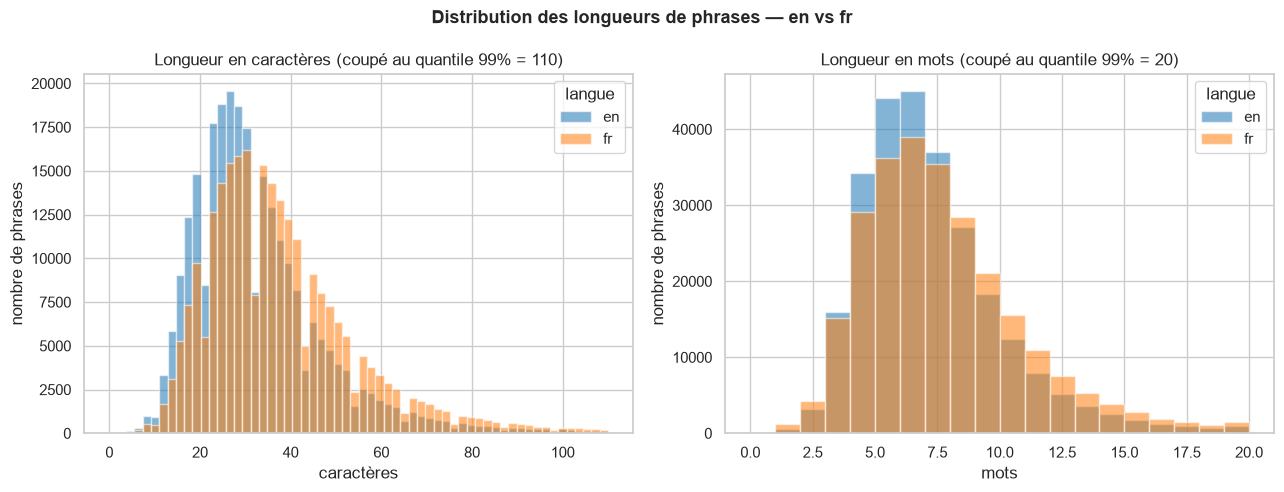

In [21]:
# Distributions des longueurs
charLimit = float(np.nanpercentile(df[[f"chars_{lang1}", f"chars_{lang2}"]].to_numpy().ravel(),
                                   lengthClipQuantile * 100))
wordLimit = float(np.nanpercentile(df[[f"words_{lang1}", f"words_{lang2}"]].to_numpy().ravel(),
                                   lengthClipQuantile * 100))

fig, axes = plt.subplots(1, 2, figsize=figSize)
for col, color in zip(textCols, ["tab:blue", "tab:orange"]):
    axes[0].hist(df[f"chars_{col}"], bins=60, range=(0, charLimit),
                 alpha=0.55, label=col, color=color)
    axes[1].hist(df[f"words_{col}"], bins=int(max(wordLimit, 10)), range=(0, wordLimit),
                 alpha=0.55, label=col, color=color)

axes[0].set_title(f"Longueur en caractères (coupé au quantile {lengthClipQuantile:.0%} = {charLimit:.0f})")
axes[0].set_xlabel("caractères")
axes[0].set_ylabel("nombre de phrases")
axes[0].legend(title="langue")

axes[1].set_title(f"Longueur en mots (coupé au quantile {lengthClipQuantile:.0%} = {wordLimit:.0f})")
axes[1].set_xlabel("mots")
axes[1].set_ylabel("nombre de phrases")
axes[1].legend(title="langue")

fig.suptitle(f"Distribution des longueurs de phrases — {lang1} vs {lang2}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

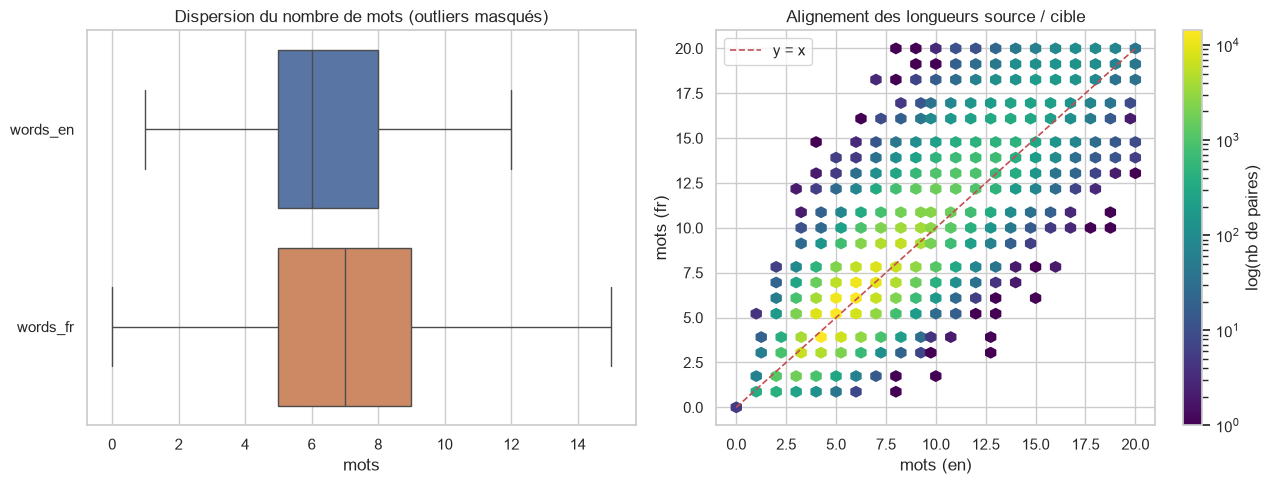

In [22]:
# Dispersion et alignement des longueurs
fig, axes = plt.subplots(1, 2, figsize=figSize)

sns.boxplot(data=df[[f"words_{lang1}", f"words_{lang2}"]], orient="h",
            ax=axes[0], showfliers=False)
axes[0].set_title("Dispersion du nombre de mots (outliers masqués)")
axes[0].set_xlabel("mots")

hb = axes[1].hexbin(df[f"words_{lang1}"], df[f"words_{lang2}"], gridsize=40,
                    extent=(0, wordLimit, 0, wordLimit), bins="log", cmap="viridis")
axes[1].plot([0, wordLimit], [0, wordLimit], "r--", linewidth=1.2, label="y = x")
axes[1].set_xlabel(f"mots ({lang1})")
axes[1].set_ylabel(f"mots ({lang2})")
axes[1].set_title("Alignement des longueurs source / cible")
axes[1].legend()
fig.colorbar(hb, ax=axes[1], label="log(nb de paires)")

plt.tight_layout()
plt.show()

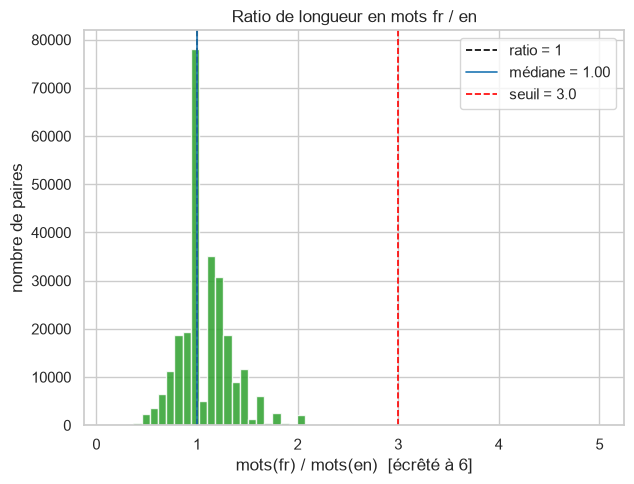

In [23]:
# Distribution du ratio de longueur
ratio = df["wordRatio"].replace([np.inf, -np.inf], np.nan).dropna()
upperClip = maxWordRatio * 2

fig, ax = plt.subplots(figsize=(figSize[0] / 2, figSize[1]))
ax.hist(ratio.clip(upper=upperClip), bins=60, color="tab:green", alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="ratio = 1")
ax.axvline(float(ratio.median()), color="tab:blue", linestyle="-", linewidth=1.2,
           label=f"médiane = {ratio.median():.2f}")
ax.axvline(maxWordRatio, color="red", linestyle="--", linewidth=1.2,
           label=f"seuil = {maxWordRatio}")
ax.set_title(f"Ratio de longueur en mots {lang2} / {lang1}")
ax.set_xlabel(f"mots({lang2}) / mots({lang1})  [écrêté à {upperClip:g}]")
ax.set_ylabel("nombre de paires")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Paires suspectes au regard des longueurs
tooShort = (df[f"words_{lang1}"] < minWords) | (df[f"words_{lang2}"] < minWords)
tooLong = (df[f"words_{lang1}"] > maxWords) | (df[f"words_{lang2}"] > maxWords)
ratioOut = ((df["wordRatio"] > maxWordRatio) | (df["wordRatio"] < 1 / maxWordRatio)).fillna(True)

flagSummary = pd.DataFrame(
    [
        {"critère": f"moins de {minWords} mot(s)", "nPaires": int(tooShort.sum())},
        {"critère": f"plus de {maxWords} mots", "nPaires": int(tooLong.sum())},
        {"critère": f"ratio de mots hors [1/{maxWordRatio:g}, {maxWordRatio:g}]",
         "nPaires": int(ratioOut.sum())},
        {"critère": "paire exactement dupliquée",
         "nPaires": int(df.duplicated(subset=textCols, keep="first").sum())},
    ]
)
flagSummary["pct"] = flagSummary["nPaires"] / len(df) * 100
display(flagSummary.set_index("critère"))

suspectMask = tooShort | tooLong | ratioOut
print(f"Paires signalées par au moins un critère de longueur: "
      f"{int(suspectMask.sum()):,} ({suspectMask.mean() * 100:.2f} %)")

,nPaires,pct
critère,,
moins de 1 mot(s),5,0.002
plus de 60 mots,84,0.032
"ratio de mots hors [1/3, 3]",270,0.102
paire exactement dupliquée,508,0.192


Paires signalées par au moins un critère de longueur: 359 (0.14 %)


In [25]:
# Cas extrêmes
displayCols = textCols + [f"words_{lang1}", f"words_{lang2}", "wordRatio"]

print(f"--- Les 5 phrases {lang1} les plus longues ---")
display(df.nlargest(5, f"words_{lang1}")[displayCols])

print(f"--- Les 5 phrases {lang2} les plus longues ---")
display(df.nlargest(5, f"words_{lang2}")[displayCols])

print("--- Les 5 ratios de longueur les plus déséquilibrés ---")
absLogRatio = np.abs(np.log(df["wordRatio"].replace([0, np.inf, -np.inf], np.nan)))
display(df.assign(absLogRatio=absLogRatio).nlargest(5, "absLogRatio")[displayCols])

print(f"--- Les 5 paires les plus courtes (mots {lang1}) ---")
display(df.nsmallest(5, f"words_{lang1}")[displayCols])

--- Les 5 phrases en les plus longues ---


,en,fr,words_en,words_fr,wordRatio
149958,"There is no such thing, at this stage of the world’s history in The United States of America, as an indepe...","Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",210,219,1.043
89878,"There is no such thing, at this stage of the world’s history in America, as an independent press. You know...","Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",206,219,1.063
111401,"Here, you have translated from the sentence in < the language you have translated from > and you created a...","Ici, vous avez traduit à partir de la phrase en < langue que vous avez traduite > et avez créé un lien ave...",132,133,1.008
244680,"Understood in its totality, the spectacle is both the result and the goal of the dominant mode of producti...","Le spectacle, compris dans sa totalité, est à la fois le résultat et le projet du mode de production exist...",129,128,0.992
114272,"Systems in which the rules are based on usage, such as languages or customary law, are condemned to become...","Les systèmes dont les règles sont basées sur l'usage, tels que les langues ou les droits coutumiers, sont ...",118,130,1.102


--- Les 5 phrases fr les plus longues ---


,en,fr,words_en,words_fr,wordRatio
89878,"There is no such thing, at this stage of the world’s history in America, as an independent press. You know...","Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",206,219,1.063
149958,"There is no such thing, at this stage of the world’s history in The United States of America, as an indepe...","Il n'y a pas, à ce stade de l'histoire mondiale aux États-Unis d'Amérique, de chose telle qu'une presse in...",210,219,1.043
111401,"Here, you have translated from the sentence in < the language you have translated from > and you created a...","Ici, vous avez traduit à partir de la phrase en < langue que vous avez traduite > et avez créé un lien ave...",132,133,1.008
114272,"Systems in which the rules are based on usage, such as languages or customary law, are condemned to become...","Les systèmes dont les règles sont basées sur l'usage, tels que les langues ou les droits coutumiers, sont ...",118,130,1.102
244680,"Understood in its totality, the spectacle is both the result and the goal of the dominant mode of producti...","Le spectacle, compris dans sa totalité, est à la fois le résultat et le projet du mode de production exist...",129,128,0.992


--- Les 5 ratios de longueur les plus déséquilibrés ---


,en,fr,words_en,words_fr,wordRatio
114891,You've hit the nail on the head!,Bingo !,8,1,0.125
24559,Let's get it over with.,Finissons-en !,6,1,0.167
76239,Let's give it a try.,Essayons !,6,1,0.167
122650,It takes one to know one.,Toi-même.,6,1,0.167
122651,It takes one to know one.,Vous-même.,6,1,0.167


--- Les 5 paires les plus courtes (mots en) ---


,en,fr,words_en,words_fr,wordRatio
257420,,,0,0,NaN
260099,,,0,0,NaN
262077,,,0,0,NaN
262979,,,0,0,NaN
264904,,,0,0,NaN


## 6. Nettoyage minimal avant l'analyse lexicale

Les sections 2 à 5 décrivent volontairement le corpus **brut** — c'est l'objet d'une AED.
À partir d'ici, l'analyse porte sur une version **nettoyée**, car les redondances biaisent
directement les mesures lexicales :

- une **paire dupliquée** compte deux fois tous ses mots : elle gonfle leur fréquence, écrase
  artificiellement le TTR et peut faire sortir un mot du statut d'hapax alors qu'il n'apparaît
  que dans une seule phrase réelle ;
- une **chaîne vide** (ou `NaN`) n'apporte aucun token mais fausse les dénominateurs.

Le nettoyage reste **minimal et réversible** : `df` (brut) est conservé intact, `dfClean` est
une nouvelle vue. On ne retire ici que ce qui est indiscutable — manquants et doublons stricts.
Les alignements 1 → N sont **conservés** : ce sont des phrases réellement différentes, pas des
doublons. Les 15 paires où `en == fr` sont laissées elles aussi (décision de nettoyage à part
entière, à trancher au moment du split).

In [26]:
# Nettoyage minimal: valeurs manquantes et paires strictement dupliquées
def basicClean(data: pd.DataFrame) -> tuple:
    """Retire les manquants et les paires dupliquées. Retourne (données, rapport)."""
    steps = [("brut", len(data), 0)]
    out = data

    # 1. NaN et chaînes vides: même problème (aucun contenu), même traitement
    before = len(out)
    out = out.dropna(subset=textCols)
    isEmpty = (out[lang1].astype(str).str.strip() == "") | (out[lang2].astype(str).str.strip() == "")
    out = out[~isEmpty]
    steps.append(("sans NaN ni chaîne vide", len(out), before - len(out)))

    # 2. paires strictement dupliquées (les alignements 1 -> N sont conservés)
    before = len(out)
    out = out.drop_duplicates(subset=textCols, keep="first")
    steps.append(("sans paire dupliquée", len(out), before - len(out)))

    report = pd.DataFrame(steps, columns=["étape", "nLignes", "supprimées"]).set_index("étape")
    report["pctRestant"] = report["nLignes"] / len(data) * 100
    return out.reset_index(drop=True), report


dfClean, cleanReport = basicClean(df)
display(cleanReport)

removed = len(df) - len(dfClean)
print(f"Corpus nettoyé: {len(dfClean):,} paires ({removed:,} retirées, {removed / len(df) * 100:.2f} %)")
print(f"df (brut) reste disponible: {len(df):,} paires")

# Contrôles
assert int(dfClean[textCols].isna().sum().sum()) == 0, "des NaN subsistent"
assert not dfClean.duplicated(subset=textCols).any(), "des paires dupliquées subsistent"
assert not (dfClean[lang1].str.strip() == "").any(), "des chaînes vides subsistent"
print("Contrôles OK: aucun NaN, aucune chaîne vide, aucune paire dupliquée.")

,nLignes,supprimées,pctRestant
étape,,,
brut,264905,0,100.000
sans NaN ni chaîne vide,264900,5,99.998
sans paire dupliquée,264396,504,99.808


Corpus nettoyé: 264,396 paires (509 retirées, 0.19 %)
df (brut) reste disponible: 264,905 paires
Contrôles OK: aucun NaN, aucune chaîne vide, aucune paire dupliquée.


## 7. Loi de Zipf

La loi de Zipf prédit que la fréquence d'un mot est inversement proportionnelle à son
rang : `f(r) ∝ 1 / r^a`, avec `a ≈ 1`. En échelle log-log, la courbe doit donc être une
**droite de pente ≈ -1**.

L'intérêt ici n'est pas de vérifier une loi connue, mais de **contrôler le corpus** :

- une courbe conforme confirme que la tokenisation produit une distribution lexicale
  naturelle — un découpage cassé (apostrophes non traitées, ponctuation collée) déforme
  visiblement la tête de la courbe ;
- comparer les deux langues révèle leur richesse morphologique relative : le français
  fléchit davantage (genres, accords, conjugaisons), il devrait donc afficher **plus de
  formes distinctes** et une proportion d'**hapax** plus élevée pour un nombre de tokens
  comparable ;
- le décrochage de la queue indique la part du vocabulaire vue une seule fois, ce qui
  conditionne directement le dimensionnement du vocabulaire sous-mots (BPE) et le taux
  de `<unk>` attendu.

Les tokens sont minusculés et débarrassés de la ponctuation de bord (`chose.` → `chose`),
mais l'apostrophe est conservée : `l'` doit rester distinct de la lettre `l`.

In [27]:
# Fréquences lexicales par langue (base de la courbe de Zipf)
from collections import Counter

# Retire la ponctuation en début/fin de token mais garde l'apostrophe:
# "chose." -> "chose", "l'" -> "l'" (l'élision reste une forme à part entière).
TOKEN_STRIP_RE = re.compile(
    r"^[^\w" + re.escape(APOSTROPHES) + r"]+|[^\w" + re.escape(APOSTROPHES) + r"]+$"
)


def normalizeToken(token: str) -> str:
    """Minuscule + retrait de la ponctuation de bord, pour l'analyse lexicale."""
    return TOKEN_STRIP_RE.sub("", token.lower())


zipfCounters = {}
for col in textCols:
    config = tokenizerConfig(col)
    counter = Counter()
    for sentence in dfClean[col].astype(str):   # corpus nettoyé (section 6)
        counter.update(normalizeToken(t) for t in tokenizeSentence(sentence, **config))
    counter.pop("", None)
    zipfCounters[col] = counter

# Fréquences triées par rang décroissant
zipfFrequencies = {
    col: np.array(sorted(counter.values(), reverse=True), dtype="int64")
    for col, counter in zipfCounters.items()
}

lexicalRows = []
for col in textCols:
    freqs = zipfFrequencies[col]
    total = int(freqs.sum())
    hapax = int((freqs == 1).sum())
    lexicalRows.append(
        {
            "langue": col,
            "tokens": total,
            "formesDistinctes": len(freqs),
            "hapax": hapax,
            "hapaxPct": hapax / len(freqs) * 100,
            "typeTokenRatio": len(freqs) / total,
            "couvTop100Pct": freqs[:100].sum() / total * 100,
            "couvTop1000Pct": freqs[:1000].sum() / total * 100,
            "couvTop10000Pct": freqs[:10000].sum() / total * 100,
        }
    )
display(pd.DataFrame(lexicalRows).set_index("langue"))

,tokens,formesDistinctes,hapax,hapaxPct,typeTokenRatio,couvTop100Pct,couvTop1000Pct,couvTop10000Pct
langue,,,,,,,,
en,1833262,27702,10538,38.041,0.015,60.039,86.224,98.424
fr,1975764,41666,16200,38.881,0.021,56.711,81.770,96.527


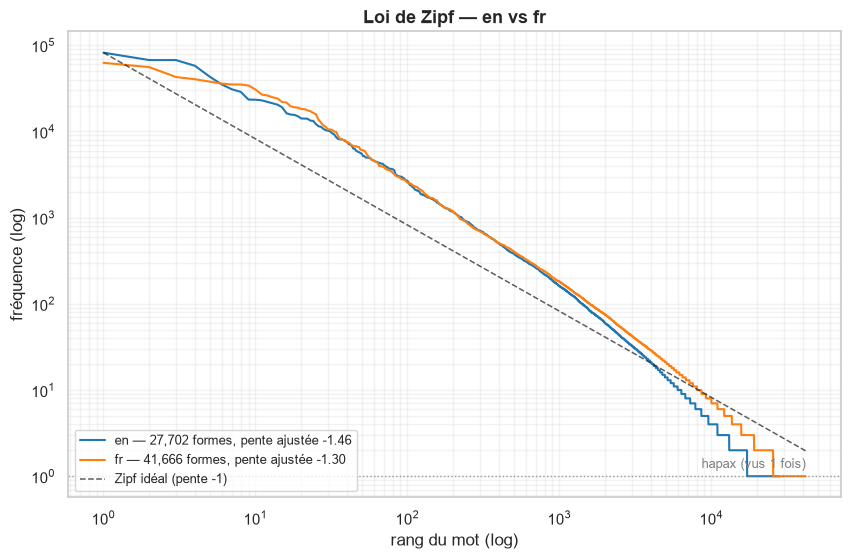

Les 10 mots les plus fréquents par langue:


,mot (en),occurrences (en),% tokens (en),mot (fr),occurrences (fr),% tokens (fr)
rang,,,,,,
1,i,82180,4.483,de,62622,3.170
2,you,67407,3.677,je,55842,2.826
3,the,67375,3.675,est,42832,2.168
4,to,57824,3.154,pas,40382,2.044
5,a,43227,2.358,la,37868,1.917
6,is,35155,1.918,le,35981,1.821
7,n't,30865,1.684,à,35128,1.778
8,do,28811,1.572,que,35064,1.775
9,of,23454,1.279,il,34155,1.729


[en] ces 10 mots pèsent 25.1 % de toutes les occurrences | pente ajustée (rangs 10-10 000): -1.464
[fr] ces 10 mots pèsent 20.8 % de toutes les occurrences | pente ajustée (rangs 10-10 000): -1.304


In [28]:
# Courbe de Zipf (log-log) pour les deux langues
def fitZipfExponent(freqs: np.ndarray, rankMin: int = 10, rankMax: int = 10000) -> float:
    """Pente de la droite log-log, ajustée hors tête et hors queue d'hapax."""
    high = min(rankMax, len(freqs))
    if high <= rankMin:
        return float("nan")
    ranks = np.arange(rankMin, high + 1)
    slope, _ = np.polyfit(np.log10(ranks), np.log10(freqs[rankMin - 1:high]), 1)
    return float(slope)


zipfColors = {lang1: "tab:blue", lang2: "tab:orange"}
fig, ax = plt.subplots(figsize=(figSize[0] / 1.5, figSize[1] * 1.15))

for col in textCols:
    freqs = zipfFrequencies[col]
    ranks = np.arange(1, len(freqs) + 1)
    slope = fitZipfExponent(freqs)
    ax.loglog(ranks, freqs, linewidth=1.5, color=zipfColors[col],
              label=f"{col} — {len(freqs):,} formes, pente ajustée {slope:.2f}")

# Référence: Zipf pur (pente -1), ancré sur le mot le plus fréquent
maxRank = max(len(f) for f in zipfFrequencies.values())
topFreq = max(int(f[0]) for f in zipfFrequencies.values())
refRanks = np.array([1, maxRank])
ax.loglog(refRanks, topFreq / refRanks, "k--", linewidth=1.1, alpha=0.7,
          label="Zipf idéal (pente -1)")

ax.axhline(1, color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.text(maxRank, 1.15, "hapax (vus 1 fois)", ha="right", va="bottom",
        fontsize=9, color="grey")

ax.set_xlabel("rang du mot (log)")
ax.set_ylabel("fréquence (log)")
ax.set_title(f"Loi de Zipf — {lang1} vs {lang2}", fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

# Les 10 mots les plus fréquents de chaque langue (tête de la courbe ci-dessus)
topN = 10
tops = {col: zipfCounters[col].most_common(topN) for col in textCols}
totals = {col: int(zipfFrequencies[col].sum()) for col in textCols}

topTable = pd.DataFrame(index=pd.RangeIndex(1, topN + 1, name="rang"))
for col in textCols:
    topTable[f"mot ({col})"] = [w for w, _ in tops[col]]
    topTable[f"occurrences ({col})"] = [c for _, c in tops[col]]
    topTable[f"% tokens ({col})"] = [c / totals[col] * 100 for _, c in tops[col]]

print(f"Les {topN} mots les plus fréquents par langue:")
display(topTable)

for col in textCols:
    share = sum(c for _, c in tops[col]) / totals[col] * 100
    print(f"[{col}] ces {topN} mots pèsent {share:.1f} % de toutes les occurrences "
          f"| pente ajustée (rangs 10-10 000): {fitZipfExponent(zipfFrequencies[col]):.3f}")

### Couverture cumulée des occurrences

La courbe de Zipf donne la fréquence rang par rang ; sa **somme cumulée** répond à la
question opérationnelle : *combien de formes faut-il connaître pour couvrir X % des
occurrences du corpus ?*

C'est exactement le dimensionnement d'un vocabulaire, et son complément
(`100 − couverture`) est le **taux d'OOV** : la proportion de tokens qui tomberaient en
`<unk>` avec un vocabulaire par mots de cette taille. La courbe est très concave — un
petit vocabulaire couvre déjà l'essentiel du texte — mais les derniers pourcents coûtent
un ordre de grandeur de formes supplémentaires, ce qui est l'argument chiffré en faveur
d'une tokenisation **sous-mots**.

Nombre de formes distinctes à connaître pour couvrir X % des occurrences:


,typesTotal,50%,80%,90%,95%,98%,99%,99.5%,99.9%
langue,,,,,,,,,
en,27702,52,528,1595,3685,8394,13267,18536,25869
fr,41666,61,827,2834,6953,15599,23688,31788,39691


Couverture (%) obtenue selon la taille du vocabulaire:


,1k,2k,5k,10k,20k,30k
langue,,,,,,
en,86.224,91.564,96.325,98.424,99.580,100.00
fr,81.770,87.545,93.375,96.527,98.627,99.41


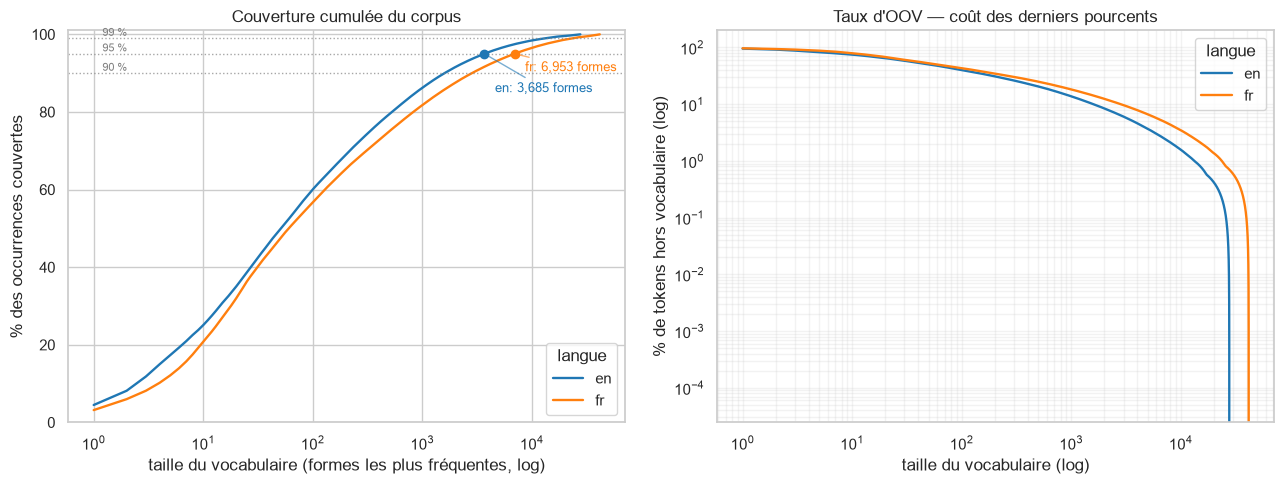

[en] 95 % des occurrences tiennent en 3,685 formes (13.3 % du vocabulaire), 99 % en 13,267 formes.
      Le dernier 1 % d'occurrences coûte 14,435 formes de plus, soit +109 % de vocabulaire pour +1 point de couverture.
[fr] 95 % des occurrences tiennent en 6,953 formes (16.7 % du vocabulaire), 99 % en 23,688 formes.
      Le dernier 1 % d'occurrences coûte 17,978 formes de plus, soit +76 % de vocabulaire pour +1 point de couverture.


In [29]:
# Couverture cumulée des occurrences en fonction de la taille du vocabulaire
coverageCurves = {
    col: np.cumsum(freqs) / freqs.sum() * 100 for col, freqs in zipfFrequencies.items()
}

# Taille de vocabulaire nécessaire pour atteindre chaque seuil de couverture
coverageTargets = [50, 80, 90, 95, 98, 99, 99.5, 99.9]
targetRows = []
for col in textCols:
    cumulative = coverageCurves[col]
    row = {"langue": col, "typesTotal": len(cumulative)}
    for target in coverageTargets:
        row[f"{target}%"] = int(np.searchsorted(cumulative, target)) + 1
    targetRows.append(row)

print("Nombre de formes distinctes à connaître pour couvrir X % des occurrences:")
display(pd.DataFrame(targetRows).set_index("langue"))

# Couverture atteinte pour des tailles de vocabulaire usuelles
vocabSizes = [1000, 2000, 5000, 10000, 20000, 30000]
sizeRows = []
for col in textCols:
    cumulative = coverageCurves[col]
    row = {"langue": col}
    for size in vocabSizes:
        capped = min(size, len(cumulative))
        row[f"{size // 1000}k"] = cumulative[capped - 1]
    sizeRows.append(row)

print("Couverture (%) obtenue selon la taille du vocabulaire:")
display(pd.DataFrame(sizeRows).set_index("langue"))

fig, axes = plt.subplots(1, 2, figsize=figSize)

for col in textCols:
    cumulative = coverageCurves[col]
    sizes = np.arange(1, len(cumulative) + 1)
    axes[0].plot(sizes, cumulative, color=zipfColors[col], linewidth=1.7, label=col)
    axes[1].plot(sizes, 100 - cumulative, color=zipfColors[col], linewidth=1.7, label=col)

for level in (90, 95, 99):
    axes[0].axhline(level, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    axes[0].text(1.2, level + 0.6, f"{level} %", fontsize=8, color="grey")

# Repère du seuil 95 % sur chaque langue
for offset, col in zip((0.55, 0.25), textCols):
    cumulative = coverageCurves[col]
    v95 = int(np.searchsorted(cumulative, 95)) + 1
    axes[0].plot([v95], [95], "o", color=zipfColors[col], markersize=6, zorder=5)
    axes[0].annotate(f"{col}: {v95:,} formes", xy=(v95, 95),
                     xytext=(v95 * 1.25, 95 - 100 * offset * 0.18),
                     fontsize=9, color=zipfColors[col],
                     arrowprops=dict(arrowstyle="-", color=zipfColors[col], alpha=0.6))

axes[0].set_xscale("log")
axes[0].set_xlabel("taille du vocabulaire (formes les plus fréquentes, log)")
axes[0].set_ylabel("% des occurrences couvertes")
axes[0].set_title("Couverture cumulée du corpus")
axes[0].set_ylim(0, 101)
axes[0].legend(title="langue", loc="lower right")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("taille du vocabulaire (log)")
axes[1].set_ylabel("% de tokens hors vocabulaire (log)")
axes[1].set_title("Taux d'OOV — coût des derniers pourcents")
axes[1].legend(title="langue")
axes[1].grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

for col in textCols:
    cumulative = coverageCurves[col]
    nTypes = len(cumulative)
    v95 = int(np.searchsorted(cumulative, 95)) + 1
    v99 = int(np.searchsorted(cumulative, 99)) + 1
    tail = nTypes - v99
    print(f"[{col}] 95 % des occurrences tiennent en {v95:,} formes ({v95 / nTypes * 100:.1f} % "
          f"du vocabulaire), 99 % en {v99:,} formes.")
    print(f"      Le dernier 1 % d'occurrences coûte {tail:,} formes de plus, "
          f"soit +{tail / v99 * 100:.0f} % de vocabulaire pour +1 point de couverture.")

### Couverture cumulée du corpus par le vocabulaire

La courbe de Zipf montre la forme de la distribution ; sa **cumulée** répond à la question
opérationnelle : *si je ne garde que les N formes les plus fréquentes, quelle part des
occurrences du corpus est-ce que je couvre ?*

C'est exactement la question du **dimensionnement du vocabulaire** d'un modèle de traduction.
Le complément de la couverture est le **taux d'OOV** — la proportion de tokens qui tomberaient
en `<unk>` avec ce vocabulaire. La courbe sature très vite (les mots grammaticaux font le gros
du volume) puis rampe interminablement dans la queue : c'est ce plateau qui rend un vocabulaire
par mots intenable et justifie le passage aux sous-mots.

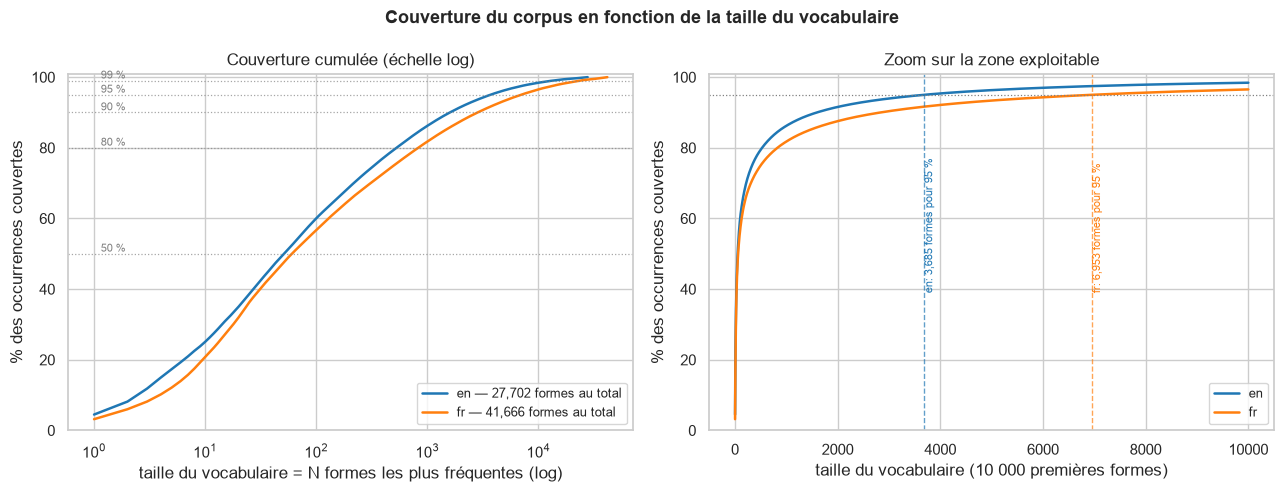

Taille de vocabulaire nécessaire pour atteindre une couverture cible:


,vocab_en,vocab_fr,ratioVocab
couvertureCiblePct,,,
50.0,52,61,1.173
80.0,528,827,1.566
90.0,1595,2834,1.777
95.0,3685,6953,1.887
98.0,8394,15599,1.858
99.0,13267,23688,1.785
99.5,18536,31788,1.715


Couverture et taux d'OOV obtenus pour des tailles de vocabulaire usuelles:


,couv_enPct,oov_enPct,couv_frPct,oov_frPct
tailleVocab,,,,
500,79.450,20.550,75.023,24.977
1000,86.224,13.776,81.770,18.230
2000,91.564,8.436,87.545,12.455
5000,96.325,3.675,93.375,6.625
10000,98.424,1.576,96.527,3.473
16000,99.298,0.702,98.066,1.934
32000,100.000,0.000,99.511,0.489


[en] 3,685 formes suffisent pour 95 % des occurrences, mais il en faut 27,702 pour 100 % — dont 10,538 hapax qui n'apportent que 0.57 % de couverture.
[fr] 6,953 formes suffisent pour 95 % des occurrences, mais il en faut 41,666 pour 100 % — dont 16,200 hapax qui n'apportent que 0.82 % de couverture.


In [30]:
# Couverture cumulée des occurrences en fonction de la taille du vocabulaire
coverage = {col: np.cumsum(zipfFrequencies[col]) / zipfFrequencies[col].sum() * 100
            for col in textCols}

coverageTargets = [50, 80, 90, 95, 98, 99, 99.5]
vocabSizes = [500, 1000, 2000, 5000, 10000, 16000, 32000]

fig, axes = plt.subplots(1, 2, figsize=figSize)

for col in textCols:
    cov = coverage[col]
    ranks = np.arange(1, len(cov) + 1)
    axes[0].plot(ranks, cov, color=zipfColors[col], linewidth=1.8,
                 label=f"{col} — {len(cov):,} formes au total")
    zoom = min(10000, len(cov))
    axes[1].plot(ranks[:zoom], cov[:zoom], color=zipfColors[col], linewidth=1.8, label=col)

for level in (50, 80, 90, 95, 99):
    axes[0].axhline(level, color="grey", linestyle=":", linewidth=0.9, alpha=0.7)
    axes[0].text(1.15, level + 0.6, f"{level} %", fontsize=8, color="grey")

axes[0].set_xscale("log")
axes[0].set_xlabel("taille du vocabulaire = N formes les plus fréquentes (log)")
axes[0].set_ylabel("% des occurrences couvertes")
axes[0].set_title("Couverture cumulée (échelle log)")
axes[0].set_ylim(0, 101)
axes[0].legend(loc="lower right", fontsize=9)

# Repère sur la cible 95 % dans la zone exploitable
for col in textCols:
    needed = int(np.searchsorted(coverage[col], 95) + 1)
    axes[1].axvline(needed, color=zipfColors[col], linestyle="--", linewidth=1, alpha=0.7)
    axes[1].text(needed, 38, f" {col}: {needed:,} formes pour 95 %",
                 fontsize=8, color=zipfColors[col], rotation=90, va="bottom")

axes[1].axhline(95, color="grey", linestyle=":", linewidth=0.9)
axes[1].set_xlabel("taille du vocabulaire (10 000 premières formes)")
axes[1].set_ylabel("% des occurrences couvertes")
axes[1].set_title("Zoom sur la zone exploitable")
axes[1].set_ylim(0, 101)
axes[1].legend(loc="lower right", fontsize=9)

fig.suptitle("Couverture du corpus en fonction de la taille du vocabulaire",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Combien de formes faut-il pour atteindre une couverture donnée ?
neededRows = []
for target in coverageTargets:
    row = {"couvertureCiblePct": target}
    for col in textCols:
        cov = coverage[col]
        row[f"vocab_{col}"] = int(min(np.searchsorted(cov, target) + 1, len(cov)))
    row["ratioVocab"] = row[f"vocab_{lang2}"] / row[f"vocab_{lang1}"]
    neededRows.append(row)
print("Taille de vocabulaire nécessaire pour atteindre une couverture cible:")
display(pd.DataFrame(neededRows).set_index("couvertureCiblePct"))

# Inversement: que couvre un vocabulaire de taille donnée ? (et quel OOV en découle)
sizeRows = []
for size in vocabSizes:
    row = {"tailleVocab": size}
    for col in textCols:
        cov = coverage[col]
        value = float(cov[min(size, len(cov)) - 1])
        row[f"couv_{col}Pct"] = value
        row[f"oov_{col}Pct"] = 100 - value
    sizeRows.append(row)
print("Couverture et taux d'OOV obtenus pour des tailles de vocabulaire usuelles:")
display(pd.DataFrame(sizeRows).set_index("tailleVocab"))

for col in textCols:
    cov = coverage[col]
    hapaxCount = int((zipfFrequencies[col] == 1).sum())
    print(f"[{col}] {int(np.searchsorted(cov, 95) + 1):,} formes suffisent pour 95 % des "
          f"occurrences, mais il en faut {len(cov):,} pour 100 % — "
          f"dont {hapaxCount:,} hapax qui n'apportent que {hapaxCount / zipfFrequencies[col].sum() * 100:.2f} % "
          f"de couverture.")

### Hapax et richesse lexicale

Deux indicateurs complémentaires de la queue de la distribution :

- les **hapax legomena** — les formes vues **une seule fois**. Elles disent quelle part du
  vocabulaire un modèle n'a aucune chance d'apprendre : c'est le vivier des futurs `<unk>` ;
- le **TTR** (*type/token ratio*) — `formes distinctes / tokens totaux`, mesure classique
  de richesse lexicale.

> ⚠️ **Le TTR brut n'est pas comparable entre deux corpus de tailles différentes.** Le
> vocabulaire croît en racine du nombre de tokens (loi de Heaps), donc le TTR **décroît**
> mécaniquement quand le corpus grandit. Ici le français compte ~8 % de tokens de plus que
> l'anglais : le comparer tel quel désavantage le français. Les deux TTR sont donc aussi
> recalculés **à budget de tokens égal**, et la courbe de croissance montre l'écart réel.

,tokens,typesDistincts,TTR,TTRpour1000tokens,hapax,hapaxPctTypes,hapaxPctTokens,disLegomena,disPctTypes
langue,,,,,,,,,
en,1833262,27702,0.015,15.111,10538,38.041,0.575,4080,14.728
fr,1975764,41666,0.021,21.089,16200,38.881,0.820,6392,15.341


Nombre de formes apparaissant exactement k fois:


,en,fr
occurrences,,
1,10538,16200
2,4080,6392
3,2133,3372
4,1404,2077
5,967,1499
6,744,1174
7,589,956
8,515,784
9,392,619


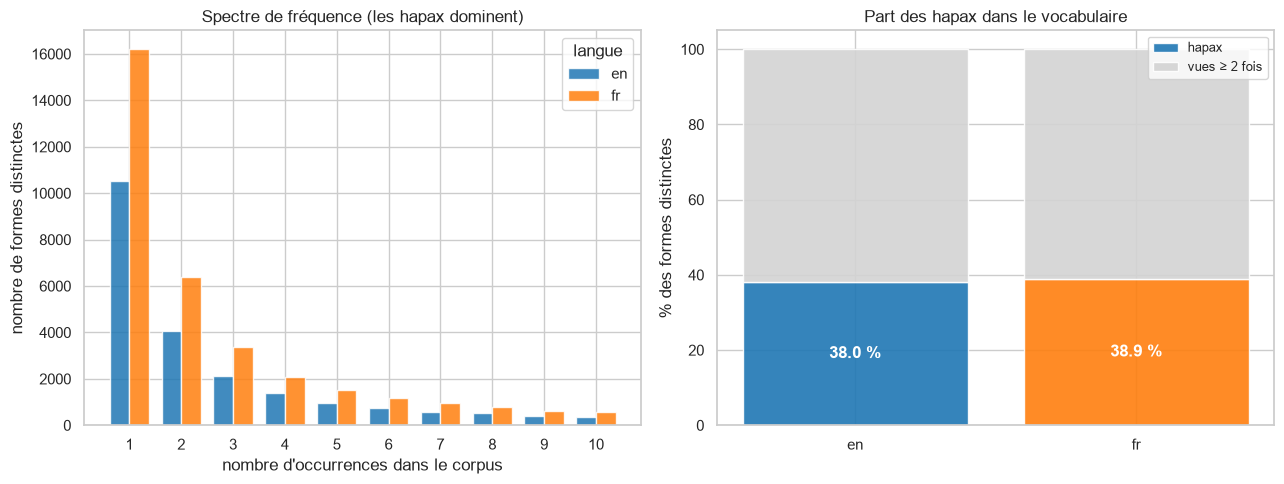

[en] 10,538 hapax — échantillon: ['bonce', 'icepack', "'heads'", 'transmigrating', 'erect', 'valet', 'lviv-based', 'wrenched', '1866', 'nash', 'brittle', 'escalade']
[fr] 16,200 hapax — échantillon: ['malcom', 'par-là', 'chevaucher', 'pâlissait', 'grinçants', 'ramenai', 'réagissez', 'renseigne-toi', 'télégénique', 'postula', 'consumer', 'trouvent-elles']


In [31]:
# Hapax et TTR (type/token ratio)
import random

hapaxRows = []
for col in textCols:
    freqs = zipfFrequencies[col]
    nTokens = int(freqs.sum())
    nTypes = len(freqs)
    hapax = int((freqs == 1).sum())
    dis = int((freqs == 2).sum())
    hapaxRows.append(
        {
            "langue": col,
            "tokens": nTokens,
            "typesDistincts": nTypes,
            "TTR": nTypes / nTokens,
            "TTRpour1000tokens": nTypes / nTokens * 1000,
            "hapax": hapax,
            "hapaxPctTypes": hapax / nTypes * 100,
            "hapaxPctTokens": hapax / nTokens * 100,
            "disLegomena": dis,
            "disPctTypes": dis / nTypes * 100,
        }
    )

hapaxDf = pd.DataFrame(hapaxRows).set_index("langue")
display(hapaxDf)

# Spectre de fréquence: combien de formes apparaissent exactement k fois
spectrum = pd.DataFrame(
    {col: [int((zipfFrequencies[col] == k).sum()) for k in range(1, 11)] for col in textCols},
    index=pd.RangeIndex(1, 11, name="occurrences"),
)
spectrumPct = spectrum / spectrum.sum().values * 100
print("Nombre de formes apparaissant exactement k fois:")
display(spectrum)

fig, axes = plt.subplots(1, 2, figsize=figSize)
width = 0.38
positions = np.arange(1, 11)
for offset, col in zip((-width / 2, width / 2), textCols):
    axes[0].bar(positions + offset, spectrum[col], width=width,
                label=col, color=zipfColors[col], alpha=0.85)
axes[0].set_xticks(positions)
axes[0].set_xlabel("nombre d'occurrences dans le corpus")
axes[0].set_ylabel("nombre de formes distinctes")
axes[0].set_title("Spectre de fréquence (les hapax dominent)")
axes[0].legend(title="langue")

hapaxShare = [hapaxDf.loc[col, "hapaxPctTypes"] for col in textCols]
restShare = [100 - v for v in hapaxShare]
axes[1].bar(textCols, hapaxShare, color=[zipfColors[c] for c in textCols],
            alpha=0.9, label="hapax")
axes[1].bar(textCols, restShare, bottom=hapaxShare, color="lightgrey",
            alpha=0.9, label="vues ≥ 2 fois")
for i, col in enumerate(textCols):
    axes[1].text(i, hapaxShare[i] / 2, f"{hapaxShare[i]:.1f} %", ha="center",
                 va="center", fontweight="bold", color="white")
axes[1].set_ylabel("% des formes distinctes")
axes[1].set_title("Part des hapax dans le vocabulaire")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# Échantillon d'hapax (souvent noms propres, coquilles, flexions rares)
sampler = random.Random(randomSeed)
for col in textCols:
    hapaxWords = [w for w, c in zipfCounters[col].items() if c == 1]
    print(f"[{col}] {len(hapaxWords):,} hapax — échantillon: "
          f"{sampler.sample(hapaxWords, min(12, len(hapaxWords)))}")

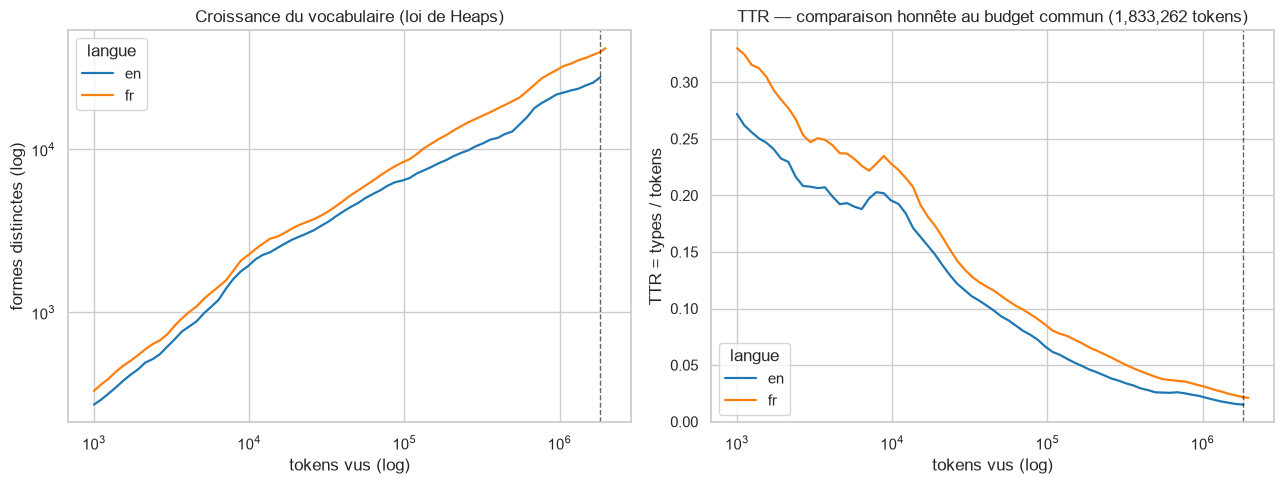

,tokensTotal,typesTotal,TTRbrut,typesAuBudgetCommun,TTRbudgetCommun
langue,,,,,
en,1833262,27702,0.015,27702,0.015
fr,1975764,41666,0.021,39577,0.022


À budget de tokens égal (1,833,262), le fr mobilise 1.43x plus de formes distinctes que le en.


In [32]:
# Croissance du vocabulaire et TTR à budget de tokens égal (loi de Heaps)
def lexicalGrowth(series: pd.Series, config: dict, checkpoints: np.ndarray) -> pd.DataFrame:
    """Parcourt le corpus une fois et relève (tokens vus, formes distinctes vues)."""
    seen = set()
    curve = []
    nTokens = 0
    idx = 0
    for sentence in series:
        for token in tokenizeSentence(sentence, **config):
            normalized = normalizeToken(token)
            if not normalized:
                continue
            nTokens += 1
            seen.add(normalized)
            while idx < len(checkpoints) and nTokens == checkpoints[idx]:
                curve.append((nTokens, len(seen)))
                idx += 1
    curve.append((nTokens, len(seen)))
    return pd.DataFrame(curve, columns=["tokens", "types"])


commonBudget = int(min(int(f.sum()) for f in zipfFrequencies.values()))
checkpoints = np.unique(np.logspace(3, np.log10(commonBudget), 70).astype("int64"))

growth = {col: lexicalGrowth(dfClean[col].astype(str), tokenizerConfig(col), checkpoints)
          for col in textCols}

fig, axes = plt.subplots(1, 2, figsize=figSize)
for col in textCols:
    g = growth[col]
    axes[0].plot(g["tokens"], g["types"], color=zipfColors[col], linewidth=1.6, label=col)
    axes[1].plot(g["tokens"], g["types"] / g["tokens"], color=zipfColors[col],
                 linewidth=1.6, label=col)

for ax in axes:
    ax.set_xscale("log")
    ax.axvline(commonBudget, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xlabel("tokens vus (log)")
    ax.legend(title="langue")

axes[0].set_yscale("log")
axes[0].set_ylabel("formes distinctes (log)")
axes[0].set_title("Croissance du vocabulaire (loi de Heaps)")
axes[1].set_ylabel("TTR = types / tokens")
axes[1].set_title(f"TTR — comparaison honnête au budget commun ({commonBudget:,} tokens)")

plt.tight_layout()
plt.show()

# TTR brut vs TTR à budget égal
fairRows = []
for col in textCols:
    g = growth[col]
    atBudget = g[g["tokens"] <= commonBudget].iloc[-1]
    total = g.iloc[-1]
    fairRows.append(
        {
            "langue": col,
            "tokensTotal": int(total["tokens"]),
            "typesTotal": int(total["types"]),
            "TTRbrut": total["types"] / total["tokens"],
            "typesAuBudgetCommun": int(atBudget["types"]),
            "TTRbudgetCommun": atBudget["types"] / atBudget["tokens"],
        }
    )
fairDf = pd.DataFrame(fairRows).set_index("langue")
display(fairDf)

ratioTypes = fairDf.loc[lang2, "typesAuBudgetCommun"] / fairDf.loc[lang1, "typesAuBudgetCommun"]
print(f"À budget de tokens égal ({commonBudget:,}), le {lang2} mobilise {ratioTypes:.2f}x "
      f"plus de formes distinctes que le {lang1}.")

## 8. Synthèse

In [33]:
# Synthèse chiffrée du début d'AED
summary = {
    "paires (brut)": f"{len(df):,}",
    "paires (nettoyé)": f"{len(dfClean):,}",
    "colonnes utiles": f"{lang1}, {lang2}",
    "splits fournis": "train uniquement",
    "valeurs manquantes": f"{int(df[textCols].isna().sum().sum())}",
    "chaînes vides": f"{int(((df[lang1].str.strip() == '') | (df[lang2].str.strip() == '')).sum())}",
    "paires exactes dupliquées": f"{int(df.duplicated(subset=textCols, keep='first').sum()):,}",
    f"phrases {lang1} dupliquées": f"{int(df[lang1].duplicated().sum()):,}",
    f"phrases {lang2} dupliquées": f"{int(df[lang2].duplicated().sum()):,}",
    f"paires {lang1} == {lang2}": f"{int(identicalMask.sum()):,}",
    f"médiane mots {lang1} (corrigé)": f"{df[f'words_{lang1}'].median():.0f}",
    f"médiane mots {lang2} (corrigé)": f"{df[f'words_{lang2}'].median():.0f}",
    f"moyenne mots {lang1} (naïf -> corrigé)":
        f"{df[f'wordsNaive_{lang1}'].mean():.2f} -> {df[f'words_{lang1}'].mean():.2f}",
    f"moyenne mots {lang2} (naïf -> corrigé)":
        f"{df[f'wordsNaive_{lang2}'].mean():.2f} -> {df[f'words_{lang2}'].mean():.2f}",
    f"médiane caractères {lang1}": f"{df[f'chars_{lang1}'].median():.0f}",
    f"médiane caractères {lang2}": f"{df[f'chars_{lang2}'].median():.0f}",
    f"ratio médian {lang2}/{lang1} (mots, naïf)": f"{df['wordRatioNaive'].median():.2f}",
    f"ratio médian {lang2}/{lang1} (mots, corrigé)": f"{df['wordRatio'].median():.2f}",
    f"formes distinctes {lang1} / {lang2}":
        f"{len(zipfFrequencies[lang1]):,} / {len(zipfFrequencies[lang2]):,}",
    f"hapax {lang1} / {lang2}":
        f"{int((zipfFrequencies[lang1] == 1).sum()):,} / {int((zipfFrequencies[lang2] == 1).sum()):,}",
    f"TTR à budget égal {lang1} / {lang2}":
        f"{fairDf.loc[lang1, 'TTRbudgetCommun']:.4f} / {fairDf.loc[lang2, 'TTRbudgetCommun']:.4f}",
    f"pente de Zipf {lang1} / {lang2}":
        f"{fitZipfExponent(zipfFrequencies[lang1]):.2f} / {fitZipfExponent(zipfFrequencies[lang2]):.2f}",
    f"vocab pour 95 % de couverture {lang1} / {lang2}":
        f"{int(np.searchsorted(coverage[lang1], 95) + 1):,} / "
        f"{int(np.searchsorted(coverage[lang2], 95) + 1):,}",
    "paires suspectes (longueur)": f"{int(suspectMask.sum()):,} ({suspectMask.mean() * 100:.2f} %)",
}

display(pd.Series(summary, name="valeur").to_frame())

,valeur
paires (brut),"264,905"
paires (nettoyé),"264,396"
colonnes utiles,"en, fr"
splits fournis,train uniquement
valeurs manquantes,0
chaînes vides,5
paires exactes dupliquées,508
phrases en dupliquées,"66,542"
phrases fr dupliquées,"18,409"
paires en == fr,15


### Points à retenir pour la suite

- **Un seul split** : le découpage train/val/test est à construire. Il devra se faire
  **par groupe de phrase source**, sinon les alignements 1 → N provoquent une fuite
  (la même phrase `en` se retrouverait dans le train et dans le test).
- **Doublons** : les paires strictement identiques sont à supprimer ; les traductions
  multiples d'une même source sont à conserver (variabilité utile) mais à regrouper au split.
- **Longueurs** : distribution très resserrée (phrases courtes de type Tatoeba) avec une
  queue longue. Elle guidera le choix de `maxLength` à la tokenisation.
- **Comptage des mots** : le découpage naïf sur les espaces est inutilisable ici — il
  sous-estime le français élidé (`l'ami` = 1 au lieu de 2) tout en le surestimant sur la
  ponctuation espacée (`chose !` = 2 au lieu de 1). Les deux biais jouent en sens inverse
  et se compensent partiellement, ce qui rend l'erreur d'autant plus trompeuse sur le ratio.
  Le comptage corrigé est la référence ; `wordsNaive_*` reste disponible pour comparaison.
- **Expansion FR/EN** : à revérifier après tokenisation sous-mots (BPE/SentencePiece),
  qui redécoupe encore différemment et détermine la vraie longueur des séquences.
- **Vocabulaire** : le français mobilise nettement plus de formes distinctes que l'anglais
  **à budget de tokens égal** — sa morphologie flexionnelle, pas un corpus plus riche. Le
  TTR brut ne le dirait pas, les deux corpus n'ayant pas la même taille.
- **Hapax** : près de 4 formes sur 10 ne sont vues qu'une fois, dans les deux langues.
  C'est l'argument décisif pour un vocabulaire **sous-mots** plutôt que par mots : un
  vocabulaire par mots condamnerait cette part entière au `<unk>`.
- **Couverture** : quelques milliers de formes suffisent à couvrir 95 % des occurrences,
  mais les derniers pourcents coûtent des dizaines de milliers de formes. C'est ce plateau,
  pas la taille du corpus, qui décide du dimensionnement du vocabulaire — et le français
  paie systématiquement plus cher que l'anglais à couverture égale.
- **Deux périmètres cohabitent** : `df` (brut) pour la description et le contrôle qualité,
  `dfClean` (sans manquants ni paires dupliquées) pour tout ce qui est lexical. Ne pas les
  mélanger dans une comparaison.

Étapes suivantes : détection de langue sur un échantillon (repérer les paires mal
étiquetées), puis stratégie de split **groupée par phrase source** et entraînement d'un
tokeniseur sous-mots dimensionné à partir des courbes ci-dessus.